#  Análise Exploratória de Dados (EDA): The Movies Dataset

In [40]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.reshaping as rsh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [41]:
caminho = '../data/interim/movies/movies_enriched.parquet'
df_movies = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (41091, 16)


---

## Análise Univariada 

Analise individual das nossas features, checando médias, mediana, desvio padrão e distribuição das colunas numericas, e a frequência das categoricas, além das classes dominantes. 

O objetivo é explorar individualmente nossas colunas em busca de padrões que se destacam e possam afetar as análises futuras

In [42]:
df_colunas = pd.DataFrame({
    "coluna": df_movies.columns,
    "dtype_pandas": df_movies.dtypes.values,
    "tipo_real": [
        df_movies[col].map(type)[0].__name__
        if not df_movies[col].dropna().empty else None
        for col in df_movies.columns
    ]
})

display(tb.estilizar_tabela(
    df=df_colunas,
    caption="Colunas do dataframe"
))

,coluna,dtype_pandas,tipo_real
0,belongs_to_collection,object,str
1,budget,float64,float
2,genres,object,ndarray
3,id,int64,int
4,original_language,object,str
5,original_title,object,str
6,popularity,float64,float
7,production_companies,object,ndarray
8,production_countries,object,ndarray
9,release_date,datetime64[ns],Timestamp


### Colunas Numéricas

In [43]:
# Análisado Colunas Numéricas Individualmente
resumo_cols_numericas = mt.numeric_summary(df_movies)
display(
    tb.estilizar_tabela(
        resumo_cols_numericas,
        caption="Relatorio colunas numéricas"
    ).format("{:,.2f}")
)

,mean,median,std,min,max,iqr,skew,kurtosis,outlier_count,outlier_%
column,,,,,,,,,,
revenue,"69,309,229.77","17,062,499.00","146,886,994.59",1.00,"2,787,965,087.00","65,635,038.00",5.13,42.70,831.00,11.31
budget,"21,956,783.82","8,820,000.00","34,512,754.61",1.00,"380,000,000.00","23,697,387.00",3.10,12.57,812.00,9.30
id,"99,432.89","52,907.00","108,089.16",2.00,"468,707.00","108,569.00",1.45,1.07,"3,736.00",9.09
vote_count,121.27,12.00,515.45,1.00,"14,075.00",36.00,9.95,136.94,"6,215.00",15.12
runtime,98.11,96.00,34.42,1.00,"1,256.00",21.00,7.00,152.15,"3,855.00",9.38
vote_average,6.01,6.10,1.27,0.00,10.00,1.50,-0.67,1.84,"1,196.00",2.91
popularity,3.19,1.33,6.24,0.00,547.49,3.79,28.66,"1,820.61","3,017.00",7.34


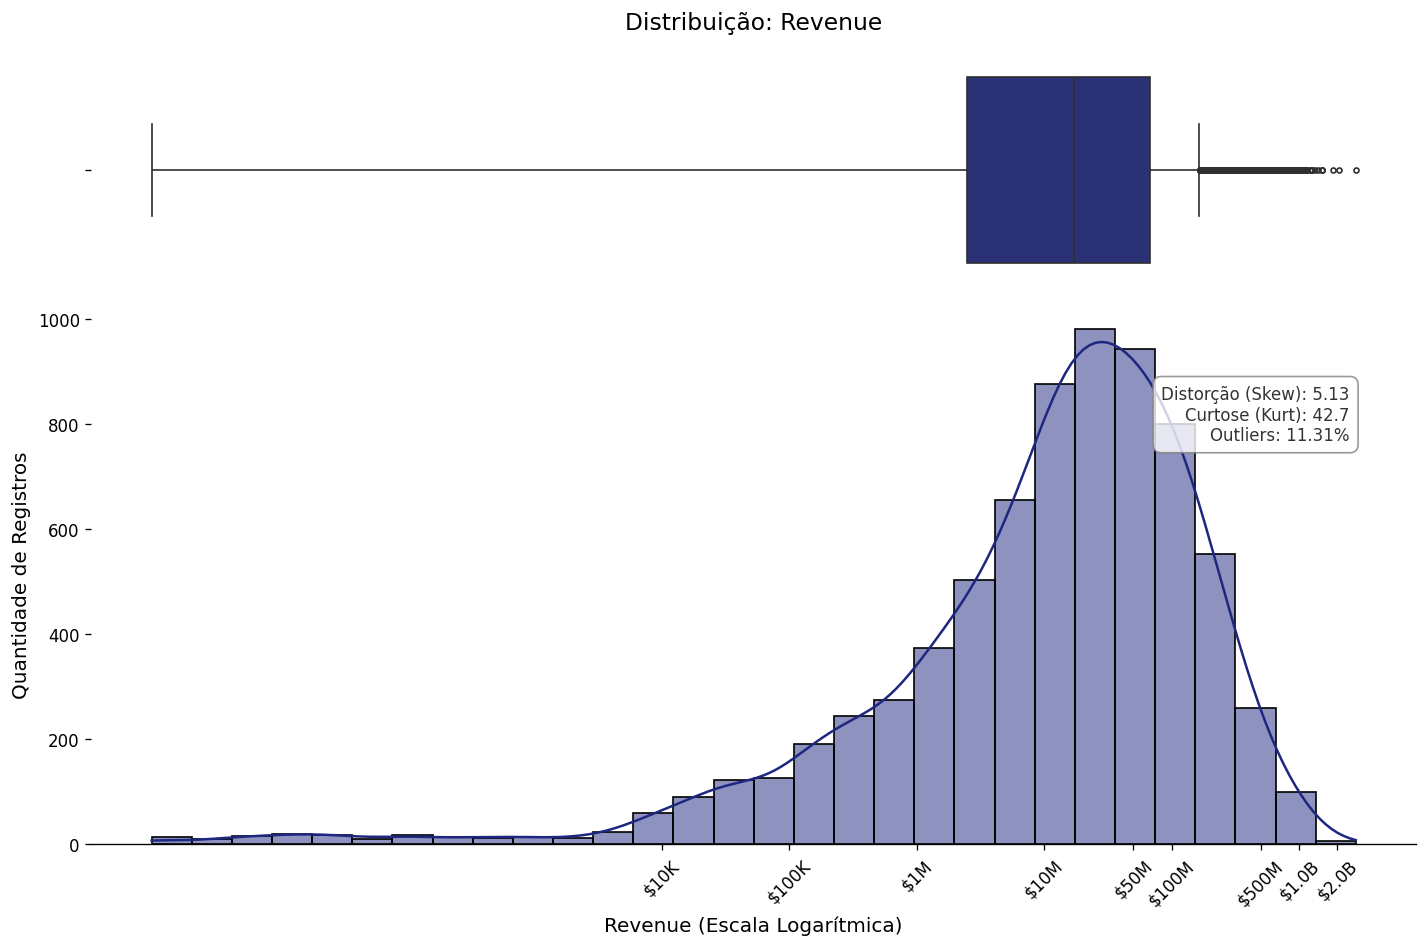

In [44]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='revenue', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='moeda'
)

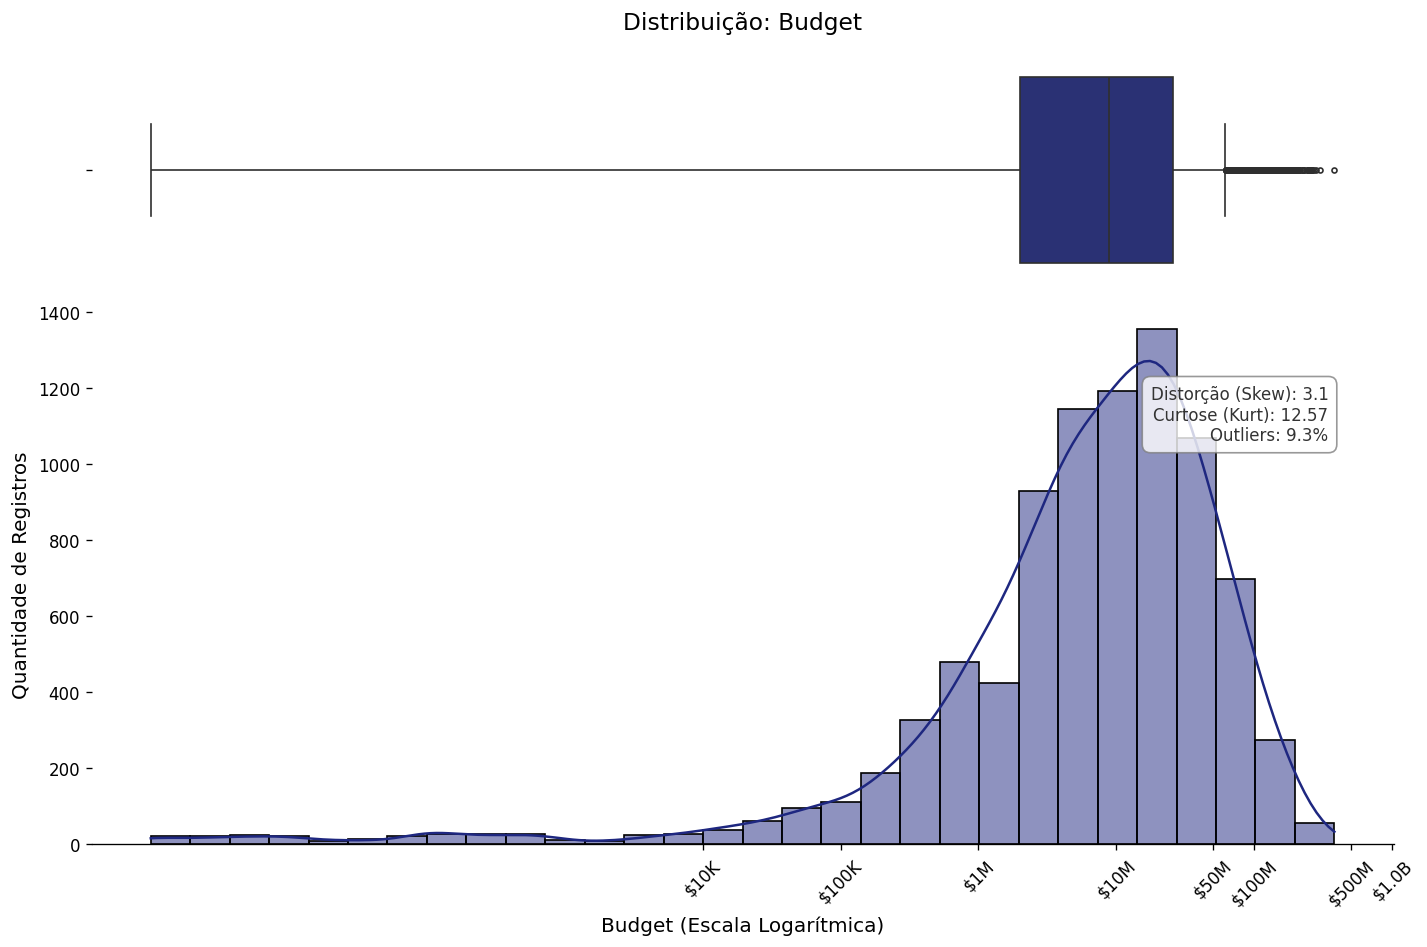

In [45]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='budget', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='moeda'
)

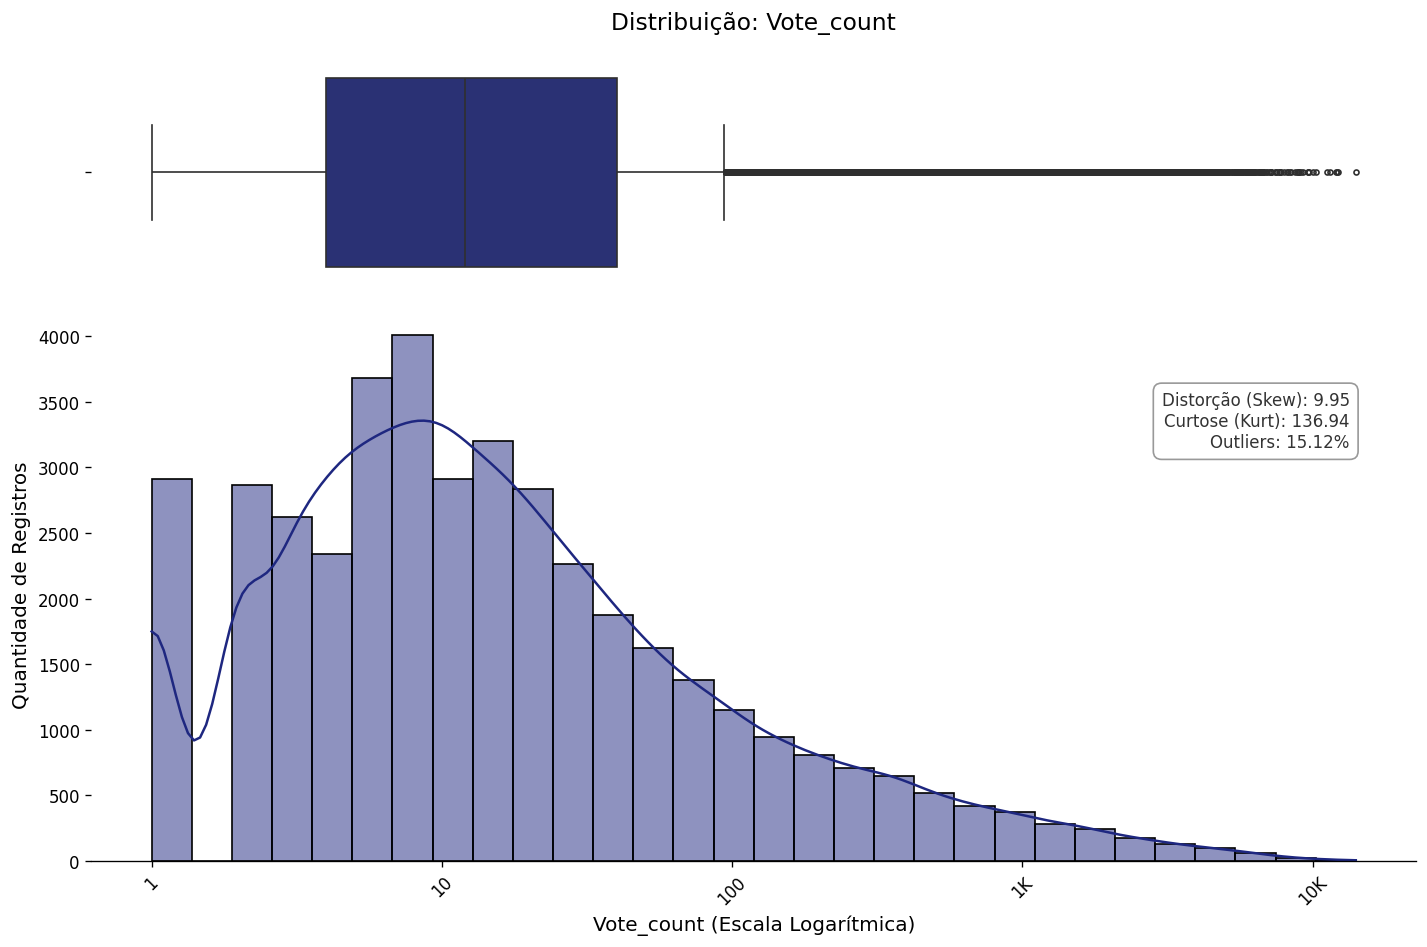

In [46]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='vote_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

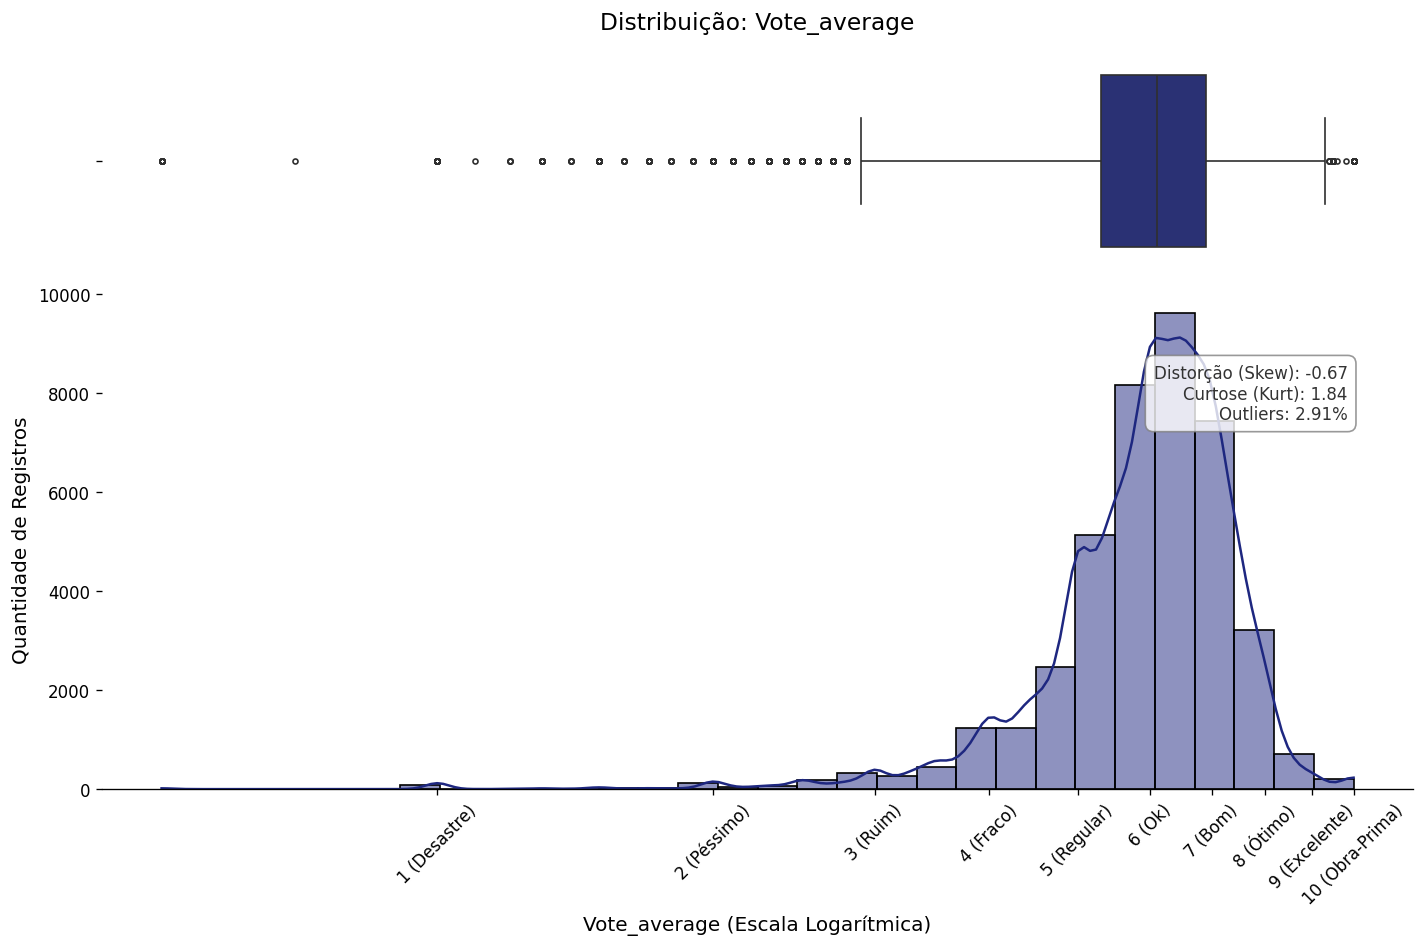

In [47]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='vote_average', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='nota_10'
)

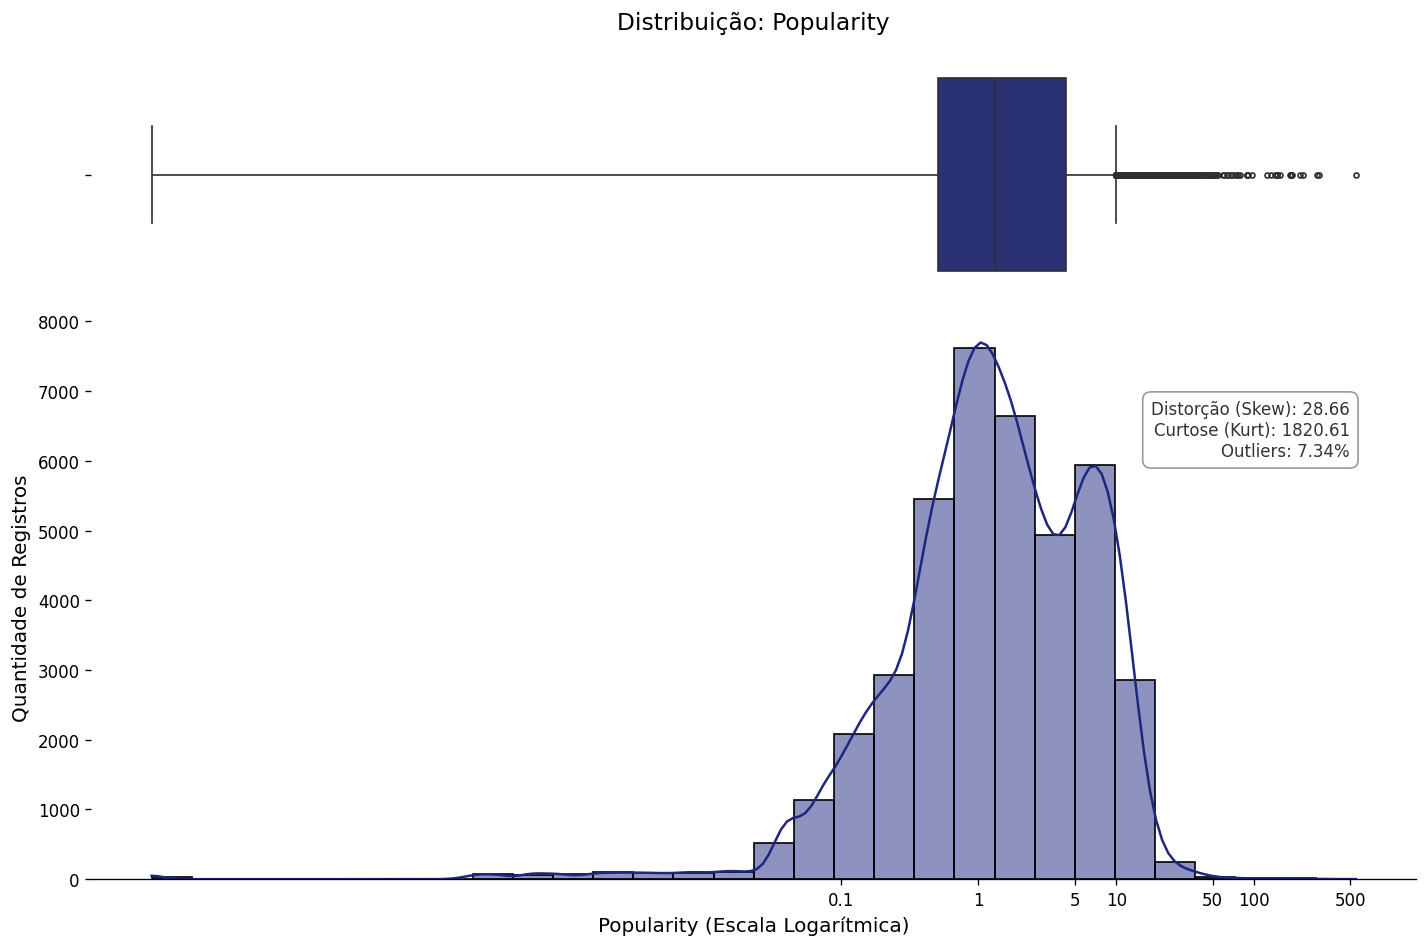

In [48]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='popularity', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True,
    tipo_dado='popularidade'
)

### Colunas Ctategoricas

In [49]:
# Análisado Colunas Categorical Individualmente
resumo_cols_categoricas = mt.categorical_summary(df_movies)
display(
    tb.estilizar_relatorio_categorias(
        resumo_cols_categoricas,
        caption="Relatorio colunas categoricas"
    )
)

,total_valid_rows,unique_categories,entropy_norm,top_values_count,top_values_pct_%
column,,,,,
original_title,41091,39206,0.997900,• Alice in Wonderland (8)• Hamlet (7)• Les Misérables (7)• The Three Musketeers (7)• Cinderella (7)• A Christmas Carol (7)• Macbeth (7)• Wuthering Heights (6)• Heidi (6)• King Lear (6),• Alice in Wonderland (0.0%)• Hamlet (0.0%)• Les Misérables (0.0%)• The Three Musketeers (0.0%)• Cinderella (0.0%)• A Christmas Carol (0.0%)• Macbeth (0.0%)• Wuthering Heights (0.0%)• Heidi (0.0%)• King Lear (0.0%)
title,41091,38233,0.996600,• Cinderella (11)• Alice in Wonderland (9)• Hamlet (8)• Les Misérables (7)• Beauty and the Beast (7)• The Three Musketeers (7)• Treasure Island (7)• A Christmas Carol (7)• Blackout (7)• The Hunters (6),• Cinderella (0.0%)• Alice in Wonderland (0.0%)• Hamlet (0.0%)• Les Misérables (0.0%)• Beauty and the Beast (0.0%)• The Three Musketeers (0.0%)• Treasure Island (0.0%)• A Christmas Carol (0.0%)• Blackout (0.0%)• The Hunters (0.0%)
genres,41091,21,0.871500,• Drama (19020)• Comedy (12165)• Thriller (7324)• Romance (6367)• Action (6302)• Horror (4526)• Crime (4086)• Adventure (3337)• Documentary (3326)• Science Fiction (2931),• Drama (46.3%)• Comedy (29.6%)• Thriller (17.8%)• Romance (15.5%)• Action (15.3%)• Horror (11.0%)• Crime (9.9%)• Adventure (8.1%)• Documentary (8.1%)• Science Fiction (7.1%)
production_companies,41091,22648,0.810000,• Companhia Não Identificada (9318)• Warner Bros. (1183)• Metro-Goldwyn-Mayer (MGM) (993)• Paramount Pictures (972)• Universal Pictures (818)• Twentieth Century Fox Film Corporation (812)• Canal+ (433)• Columbia Pictures Corporation (427)• Columbia Pictures (420)• New Line Cinema (277),• Companhia Não Identificada (22.7%)• Warner Bros. (2.9%)• Metro-Goldwyn-Mayer (MGM) (2.4%)• Paramount Pictures (2.4%)• Universal Pictures (2.0%)• Twentieth Century Fox Film Corporation (2.0%)• Canal+ (1.1%)• Columbia Pictures Corporation (1.0%)• Columbia Pictures (1.0%)• New Line Cinema (0.7%)
production_countries,41091,159,0.517800,• United States of America (20064)• País Não Identificado (4511)• United Kingdom (3949)• France (3736)• Germany (2096)• Italy (1848)• Canada (1663)• Japan (1560)• Russia (859)• Spain (853),• United States of America (48.8%)• País Não Identificado (11.0%)• United Kingdom (9.6%)• France (9.1%)• Germany (5.1%)• Italy (4.5%)• Canada (4.0%)• Japan (3.8%)• Russia (2.1%)• Spain (2.1%)
spoken_languages,41091,76,0.503600,• English (27163)• Français (3945)• Deutsch (2447)• Idioma Não Identificado (2432)• Español (2249)• Italiano (2043)• 日本語 (1665)• Pусский (1478)• 普通话 (765)• हिन्दी (635),• English (66.1%)• Français (9.6%)• Deutsch (6.0%)• Idioma Não Identificado (5.9%)• Español (5.5%)• Italiano (5.0%)• 日本語 (4.1%)• Pусский (3.6%)• 普通话 (1.9%)• हिन्दी (1.5%)
original_language,41091,85,0.322200,• en (29495)• fr (2226)• ja (1280)• it (1134)• de (927)• es (848)• ru (752)• hi (463)• ko (441)• zh (397),• en (71.8%)• fr (5.4%)• ja (3.1%)• it (2.8%)• de (2.3%)• es (2.1%)• ru (1.8%)• hi (1.1%)• ko (1.1%)• zh (1.0%)
belongs_to_collection,41091,1659,0.148100,• Sem Coleção (36751)• James Bond Collection (26)• Zatôichi: The Blind Swordsman (26)• The Carry On Collection (25)• Pokémon Collection (22)• Charlie Chan (Sidney Toler) Collection (21)• Totò Collection (19)• Godzilla (Showa) Collection (16)• The Bowery Boys (15)• Dragon Ball Z (Movie) Collection (15),• Sem Coleção (89.4%)• James Bond Collection (0.1%)• Zatôichi: The Blind Swordsman (0.1%)• The Carry On Collection (0.1%)• Pokémon Collection (0.1%)• Charlie Chan (Sidney Toler) Collection (0.1%)• Totò Collection (0.0%)• Godzilla (Showa) Collection (0.0%)• The Bowery Boys (0.0%)• Dragon Ball Z (Movie) Collection (0.0%)


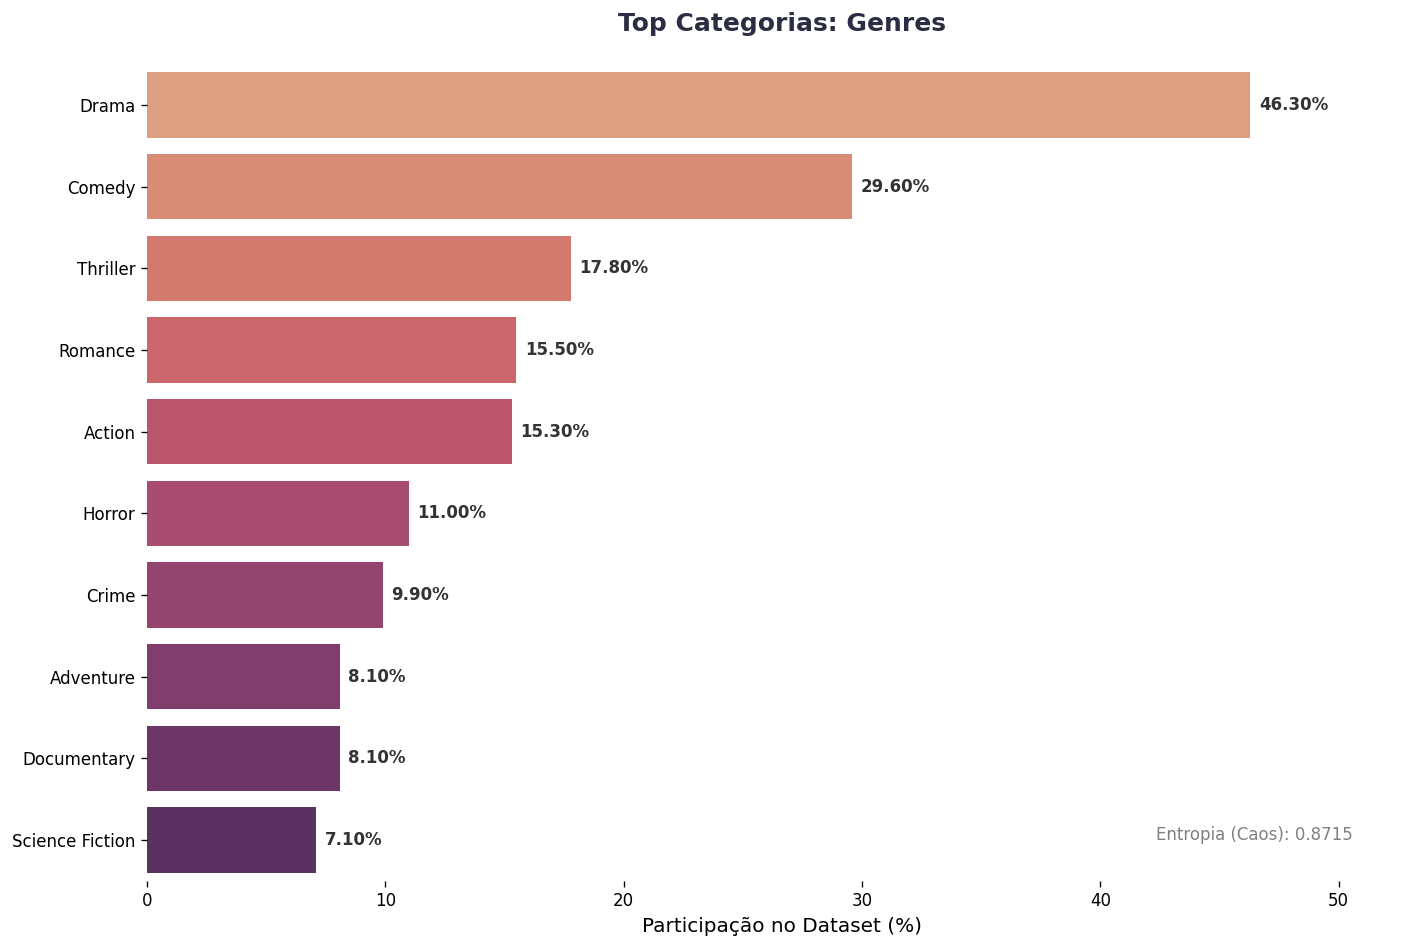

In [50]:
graf.grafico_top_categorias(df_movies, 'genres', resumo_cols_categoricas)

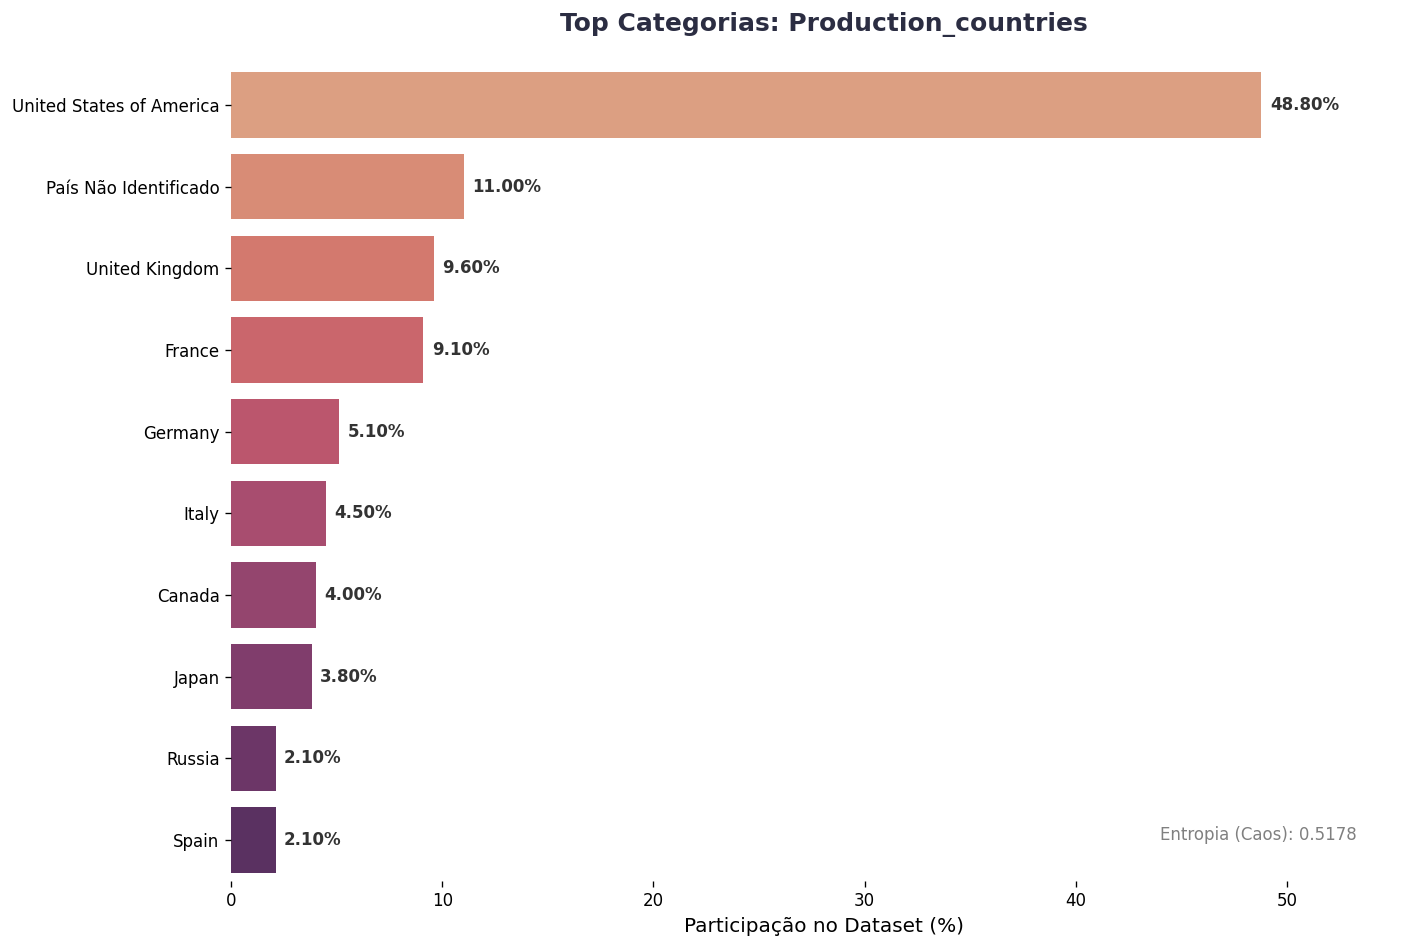

In [51]:
graf.grafico_top_categorias(df_movies, 'production_countries', resumo_cols_categoricas)

c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry

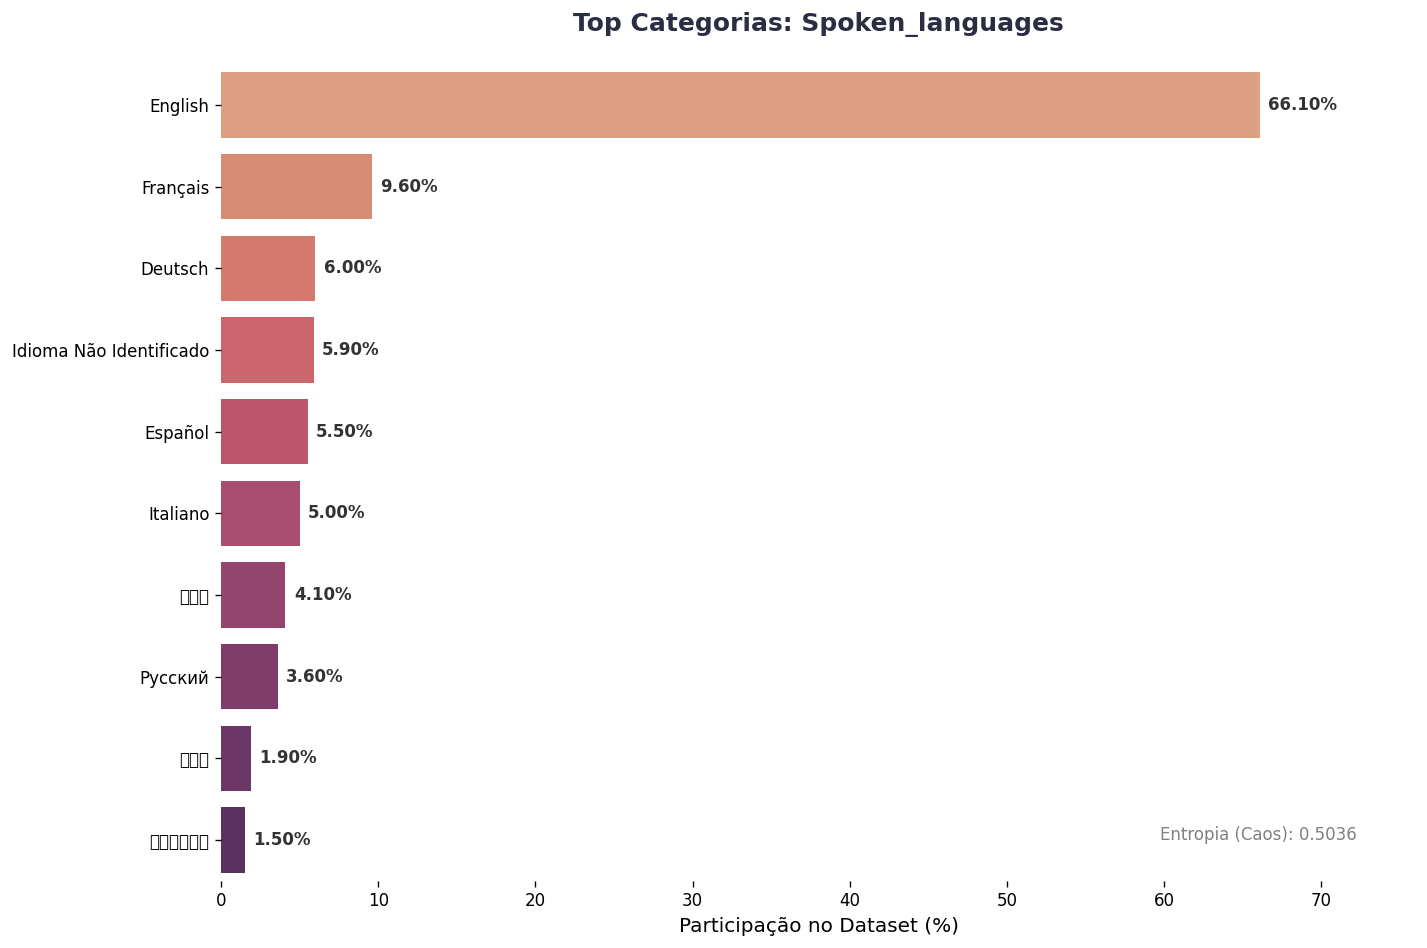

In [52]:
graf.grafico_top_categorias(df_movies, 'spoken_languages', resumo_cols_categoricas)

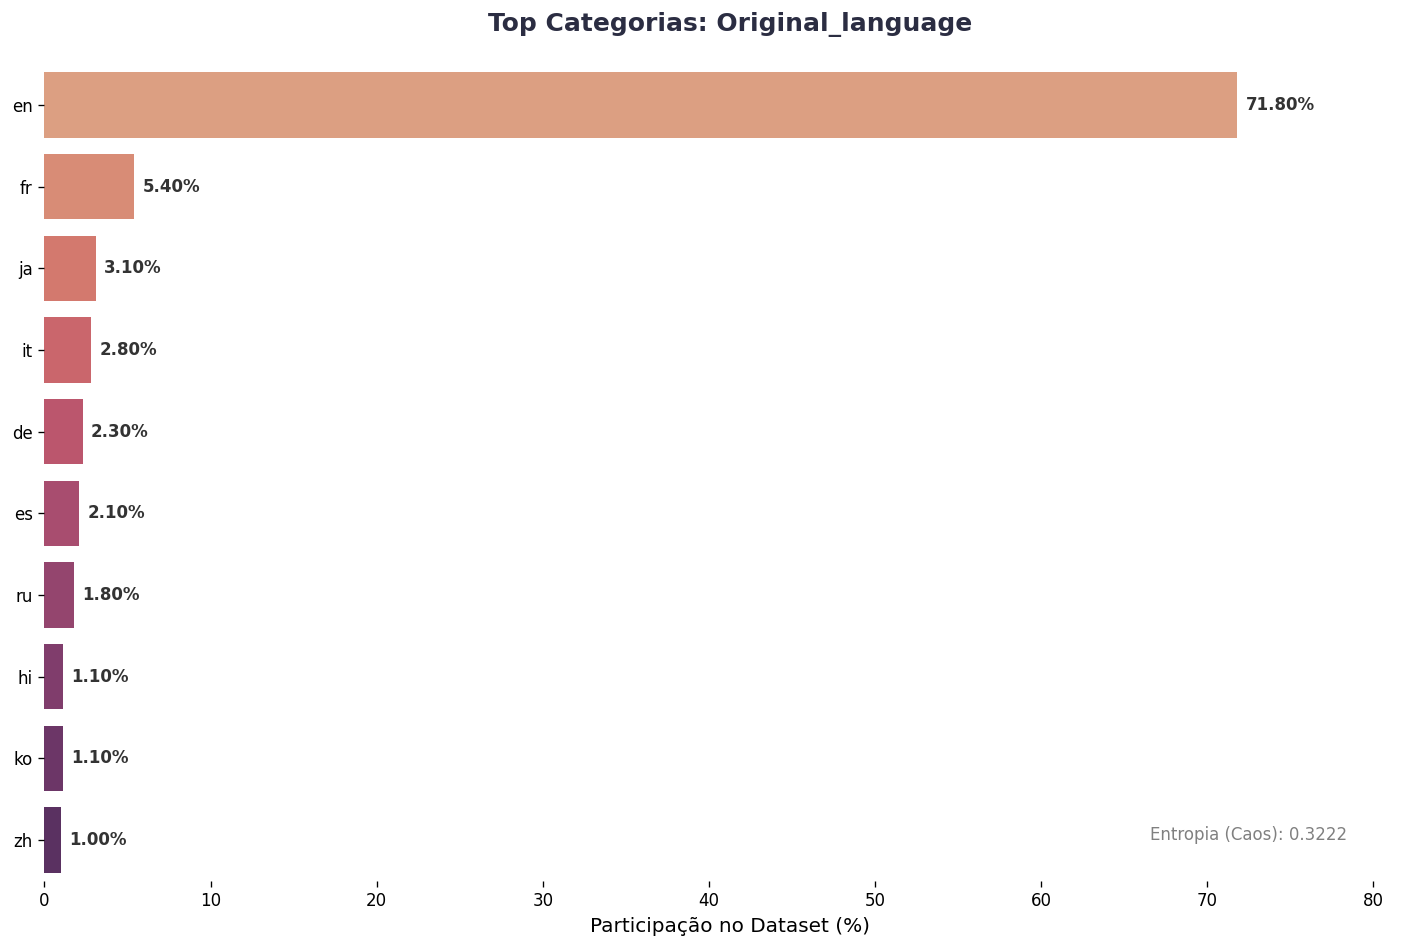

In [53]:
graf.grafico_top_categorias(df_movies, 'original_language', resumo_cols_categoricas)

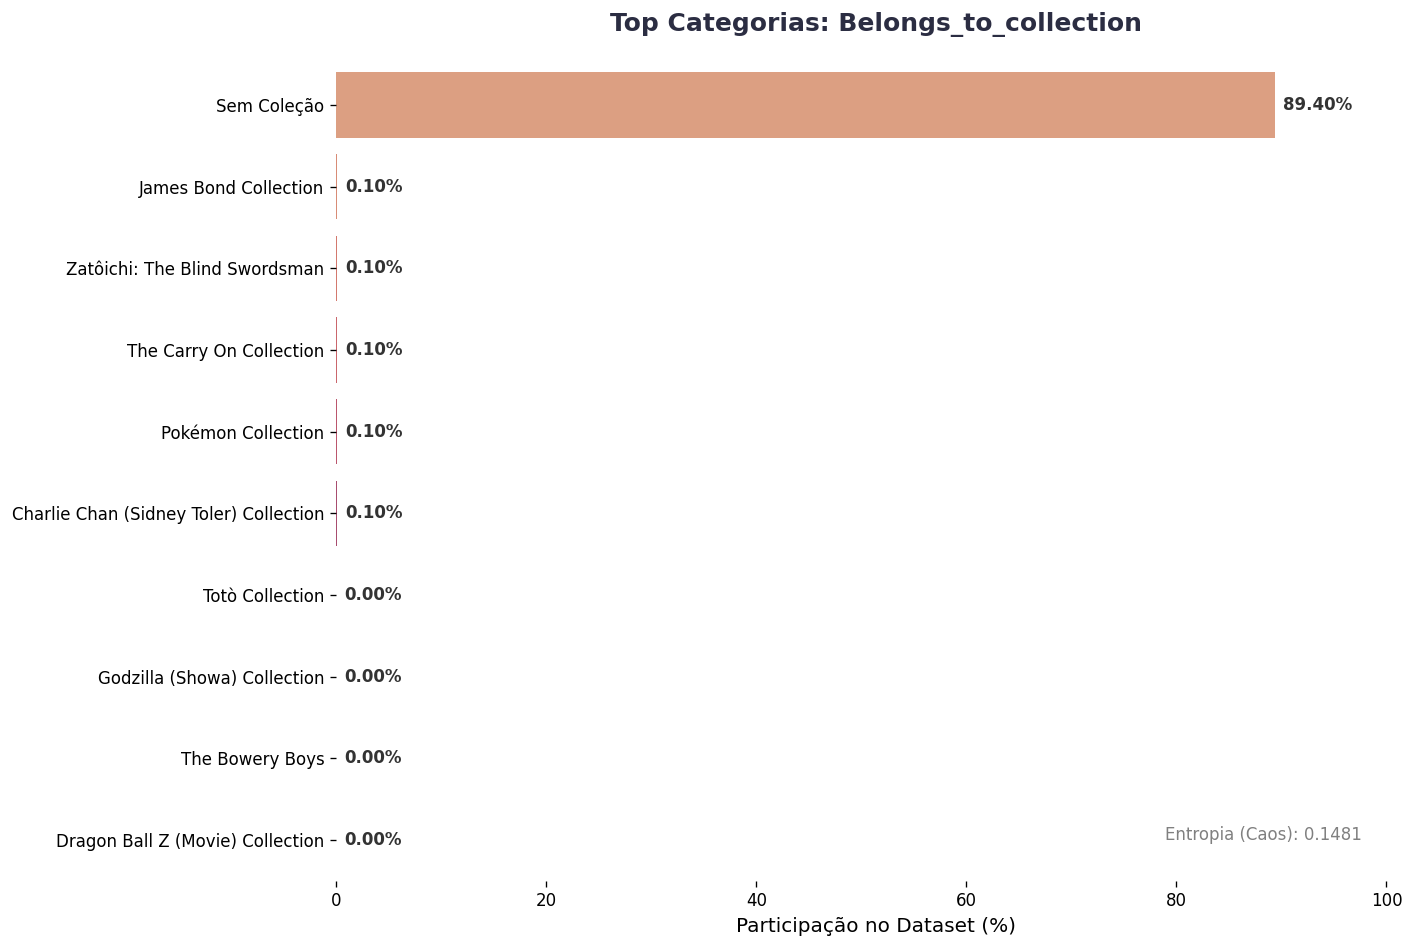

In [54]:
graf.grafico_top_categorias(df_movies, 'belongs_to_collection', resumo_cols_categoricas)

### Colunas de Tempo

In [55]:
relatorio_cols_date = mt.datetime_summary(df_movies)

display(
    tb.estilizar_tabela(
        relatorio_cols_date,
        caption="Relatorio colunas date"
    )
)

,min,max,range_years,unique_dates,most_frequent_year,most_frequent_month
column,,,,,,
release_date,1874-12-09,2018-04-04,143,16394,2014,1


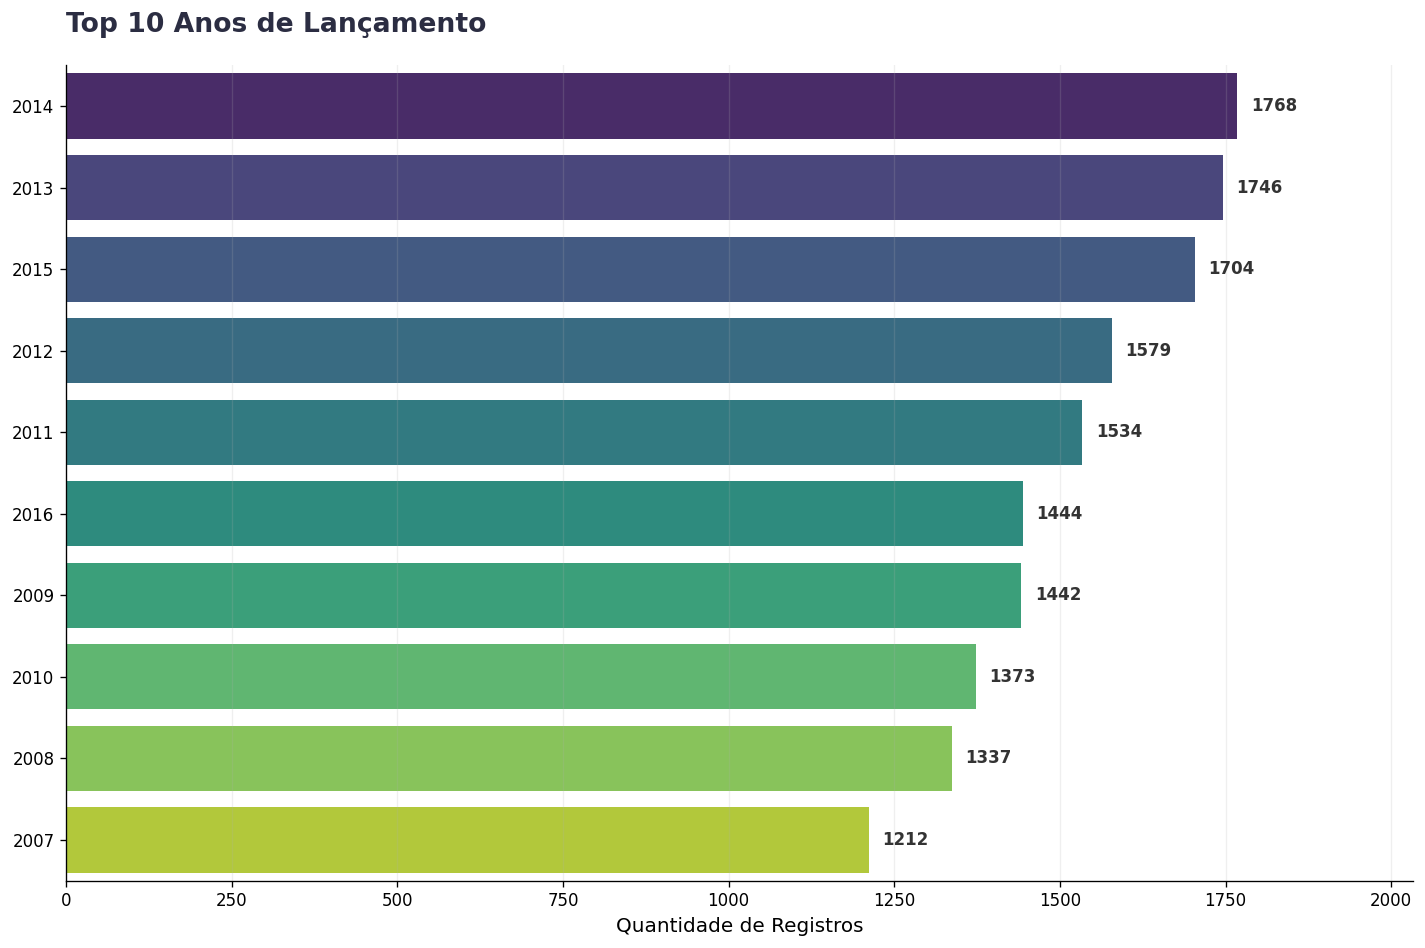

In [56]:
graf.graficos_top_release(df_movies, 'release_date', data='year')

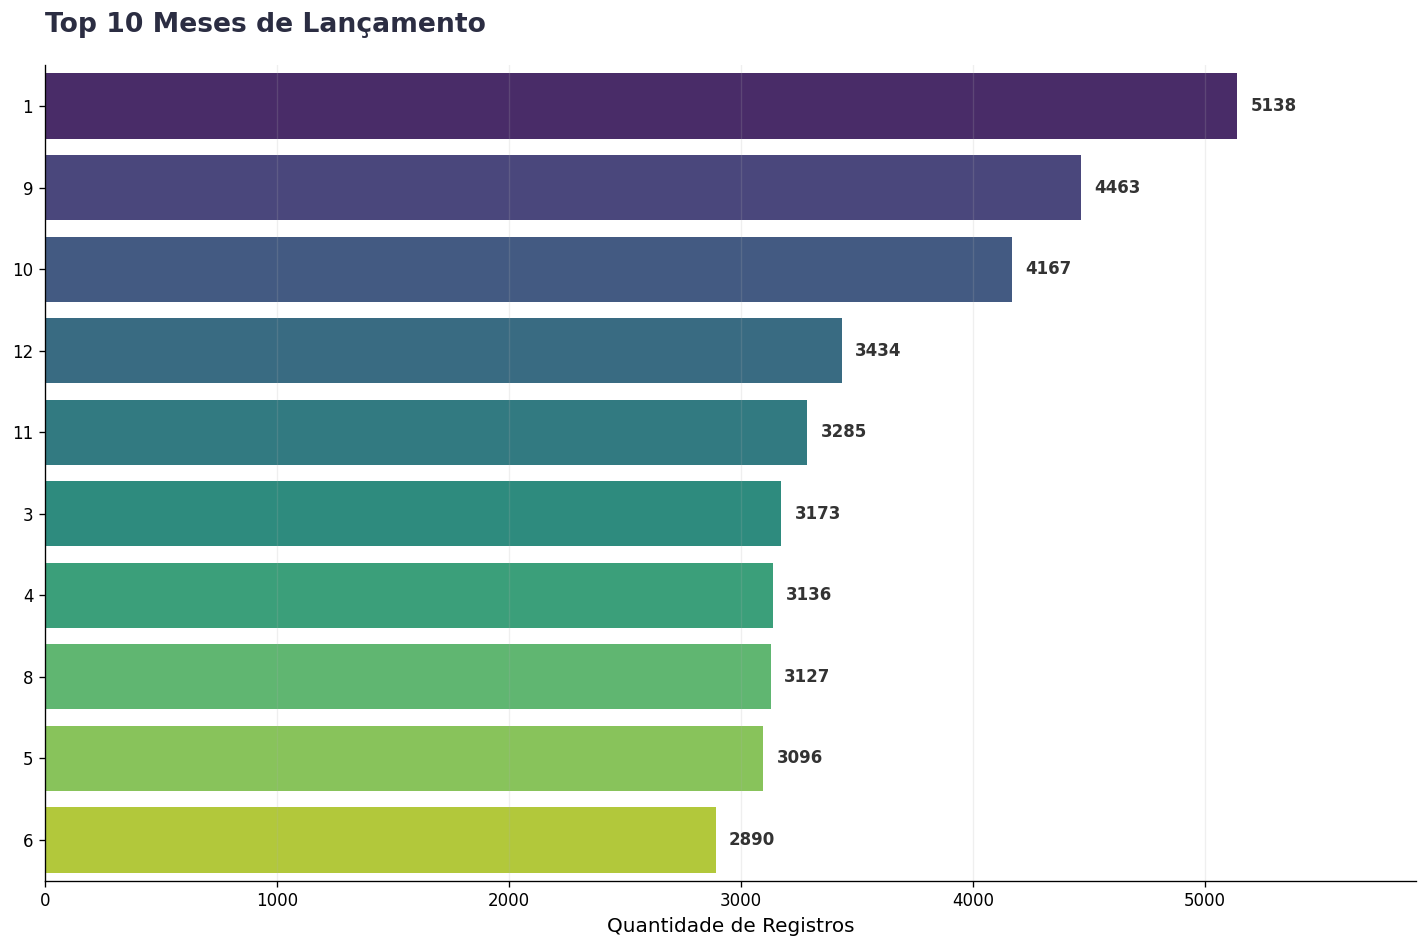

In [57]:
graf.graficos_top_release(df_movies, 'release_date', data='month')

## Conclusões da Análise Univariada (Resumo)

### 1. Diagnóstico Estatístico (Métricas Numéricas)
* **Finanças e Engajamento (`revenue`, `budget`, `vote_count`):** Distribuição de **cauda longa** com assimetria extrema. O mercado é polarizado: a esmagadora maioria dos filmes tem baixo orçamento, pouca bilheteria e poucas avaliações, enquanto uma elite de blockbusters concentra o dinheiro e a atenção do público.
* **Avaliações (`vote_average`):** Segue uma **Distribuição Normal** perfeita, concentrada entre **6.0 e 7.5**. Notas extremas (0 ou 10) são raridades; a maior parte do catálogo habita a zona do entretenimento aceitável.

### 2. Padrões Categoriais
* **Concentração Geográfica e Linguística:** Baixa entropia, evidenciando a dominância absoluta de Hollywood (EUA) e do idioma inglês.
* **Diversidade de Gêneros:** Alta entropia. *Drama* e *Comédia* lideram em volume, mas o ecossistema de gêneros é bem distribuído.
* **Franquias:** Obras isoladas são a regra; coleções são exceções estruturais.

### 3. Comportamento Temporal
* **Evolução:** Abrange **143 anos** de cinema (1874 a 2018) com altíssima granularidade (**16.394 datas únicas**), tendo seu **pico histórico em 2014**.
* **Sazonalidade:** O **mês 1 (Janeiro)** lidera os registros, o que indica uma provável padronização de cadastro para filmes antigos, além de festivais e relançamentos.

### 4. Auditoria de Data Quality
* **Sujeira nos Dados:** Identificação de orçamentos e faturamentos irreais (ex: \$10), caracterizados como erros de preenchimento do TMDB e não como produções independentes legítimas.
* **Mitigação:** Aplicação de um filtro temporário (`>= 1_000_000`) para proteger os gráficos atuais, com substituição definitiva desses valores truncados por `NaN` na etapa de *Data Cleaning*.

---
## Análise Bivariada

In [58]:
# Verifica quais valores são menores que zero (< 0)
display(tb.estilizar_tabela(
    df=(df_movies.select_dtypes(include='number') < 0)
        .sum()
        .to_frame(name='contagem'
    ),
    caption="Quantidade de valores impossíveis (negativos) por coluna:"
))

,contagem
budget,0
id,0
popularity,0
revenue,0
runtime,0
vote_average,0
vote_count,0


## Numérica VS Numérica

In [59]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='pearson')['vote_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='spearman')['vote_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
vote_count,1.000000
revenue,0.781428
budget,0.618293
popularity,0.557913
vote_average,0.124841
runtime,0.107405
id,-0.052231


,Correlação
vote_count,1.000000
popularity,0.885722
revenue,0.726973
budget,0.657671
runtime,0.240864
vote_average,0.173598
id,-0.395972


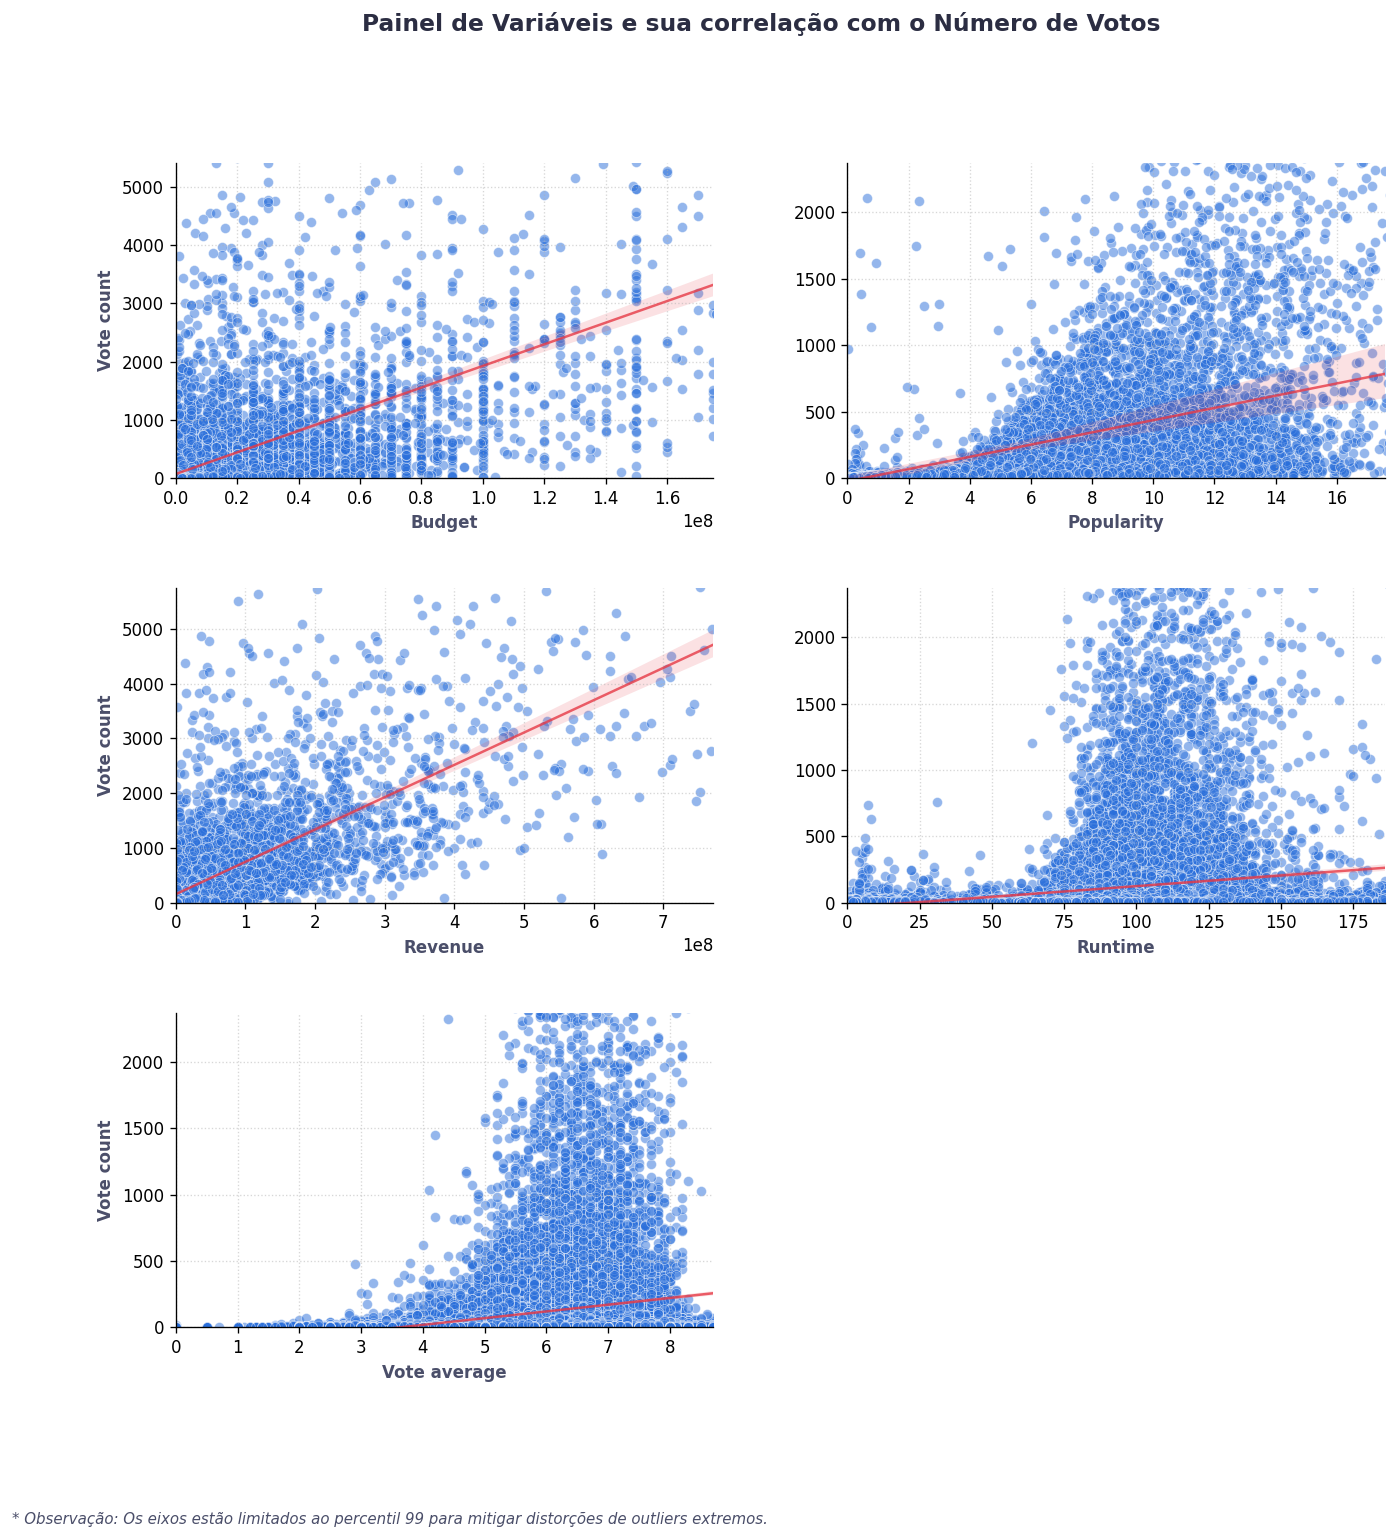

In [60]:
# Passa a lista direto no eixo X
colunas_numericas = df_movies.select_dtypes(include='number').columns

graf.grafico_corr_scatter(
    df_plot=df_movies,
    coluna_x=colunas_numericas.drop(['vote_count', 'id']), 
    coluna_y='vote_count',
    titulo='Painel de Variáveis e sua correlação com o Número de Votos',
    quant_grafs=len(colunas_numericas.drop(['vote_count', 'id']))
)

In [61]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='pearson')['vote_average']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='spearman')['vote_average']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
vote_average,1.000000
revenue,0.149229
vote_count,0.124841
runtime,0.102999
popularity,0.098950
budget,0.074281
id,-0.004505


,Correlação
vote_average,1.000000
vote_count,0.173598
runtime,0.156225
popularity,0.109147
revenue,0.108567
budget,0.030421
id,-0.068177


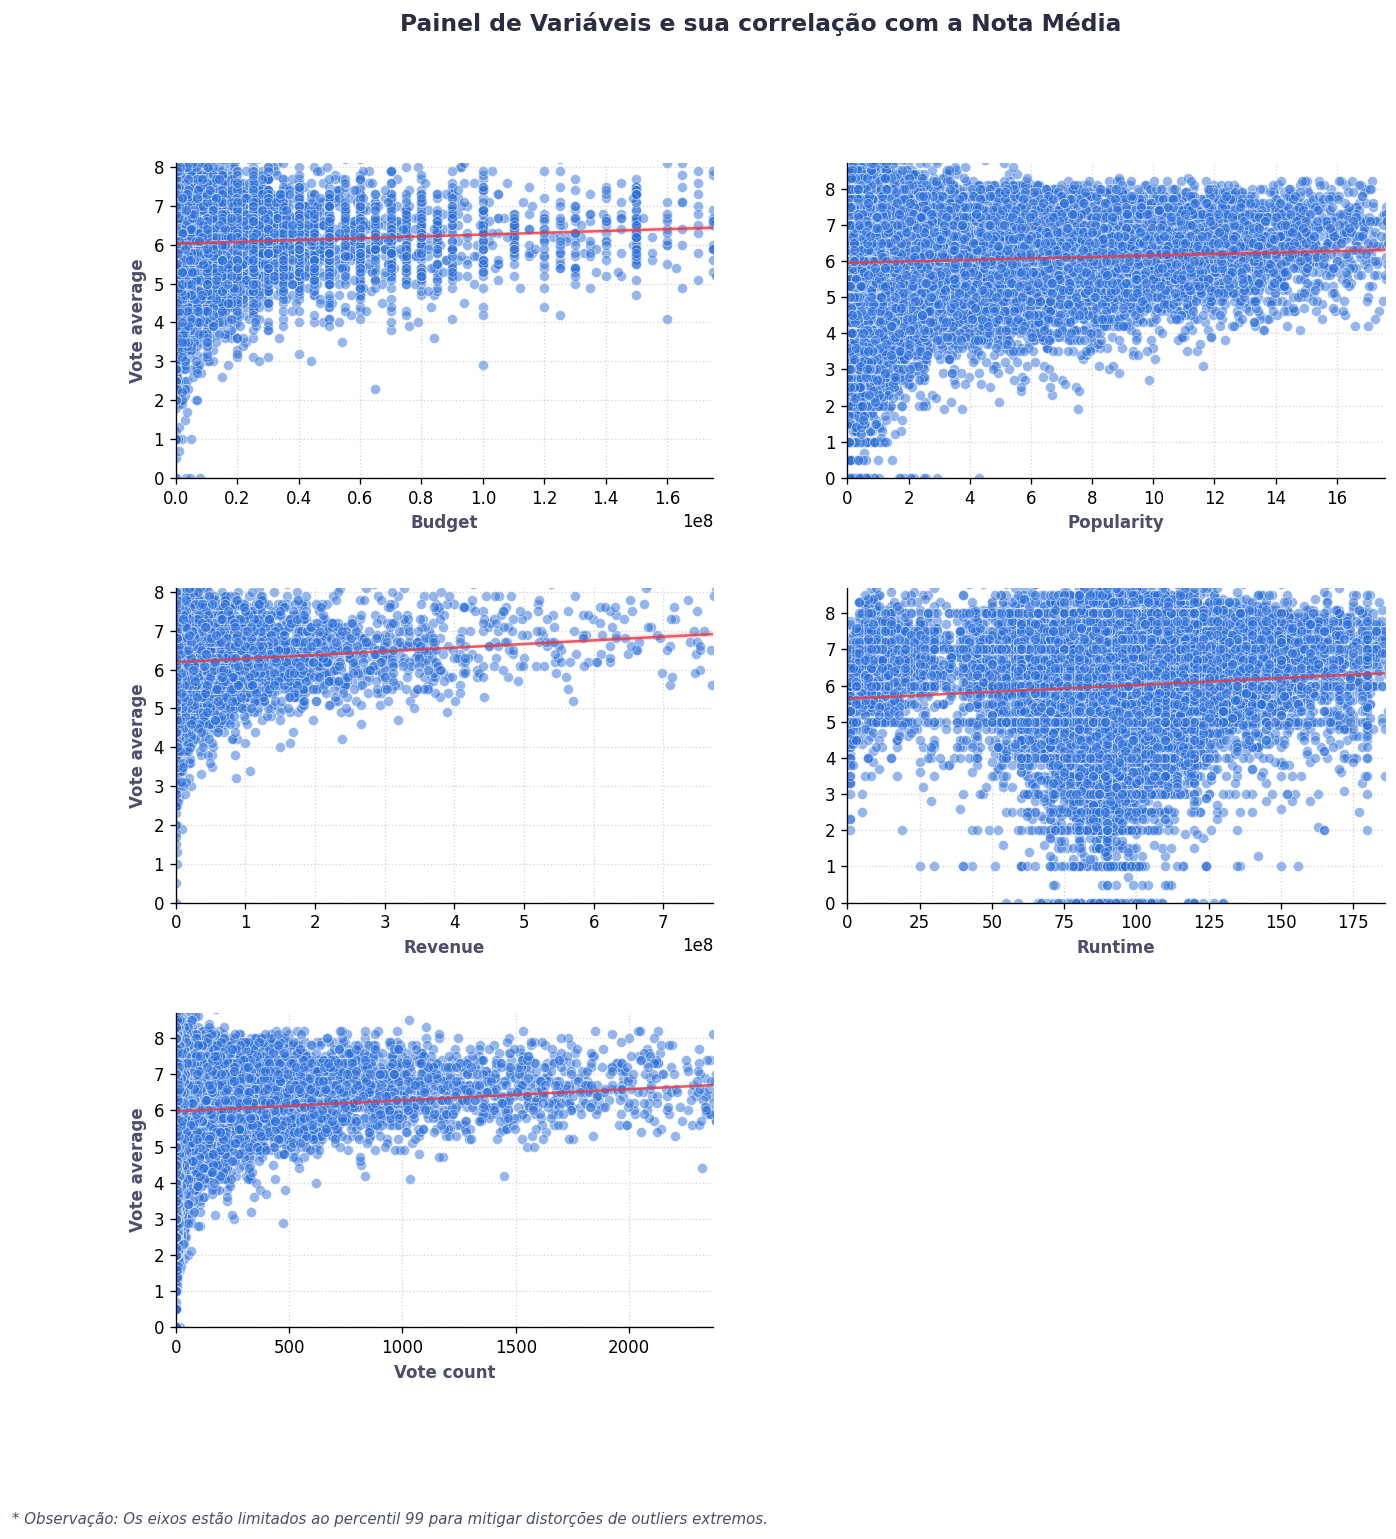

In [62]:
graf.grafico_corr_scatter(
    df_plot=df_movies,
    coluna_x=colunas_numericas.drop(['vote_average', 'id']), 
    coluna_y='vote_average',
    titulo='Painel de Variáveis e sua correlação com a Nota Média',
    quant_grafs=len(colunas_numericas.drop(['vote_average', 'id']))
)

In [63]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='pearson')['popularity']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='spearman')['popularity']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
popularity,1.000000
vote_count,0.557913
revenue,0.456920
budget,0.364791
runtime,0.105987
vote_average,0.098950
id,-0.055626


,Correlação
popularity,1.000000
vote_count,0.885722
budget,0.604398
revenue,0.595985
runtime,0.260465
vote_average,0.109147
id,-0.380278


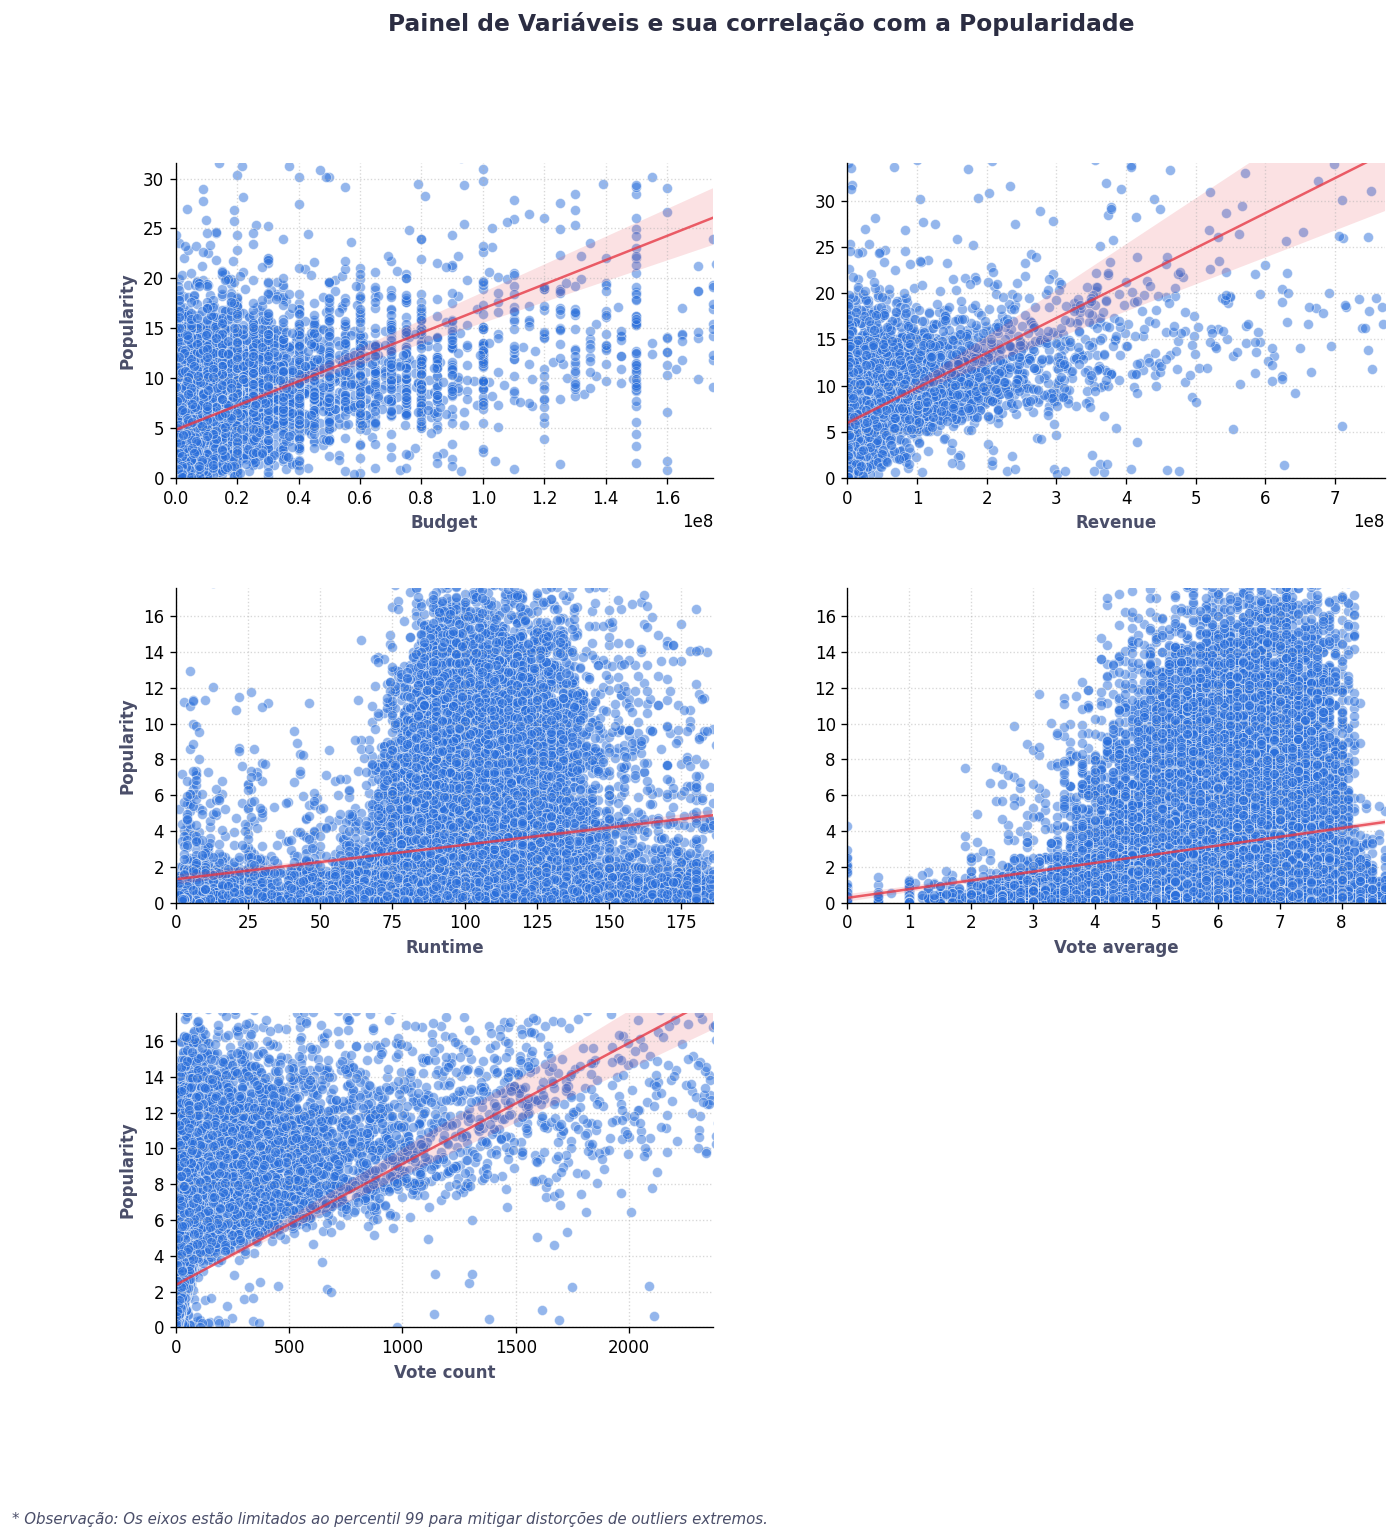

In [64]:
graf.grafico_corr_scatter(
    df_plot=df_movies,
    coluna_x=colunas_numericas.drop(['popularity', 'id']), 
    coluna_y='popularity',
    titulo='Painel de Variáveis e sua correlação com a Popularidade',
    quant_grafs=len(colunas_numericas.drop(['popularity', 'id']))
)

In [65]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='pearson')['revenue']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_movies.select_dtypes(include='number')
        .corr(method='spearman')['revenue']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
revenue,1.000000
vote_count,0.781428
budget,0.729991
popularity,0.456920
runtime,0.203714
vote_average,0.149229
id,-0.018880


,Correlação
revenue,1.000000
vote_count,0.726973
budget,0.709392
popularity,0.595985
runtime,0.260934
vote_average,0.108567
id,-0.317994


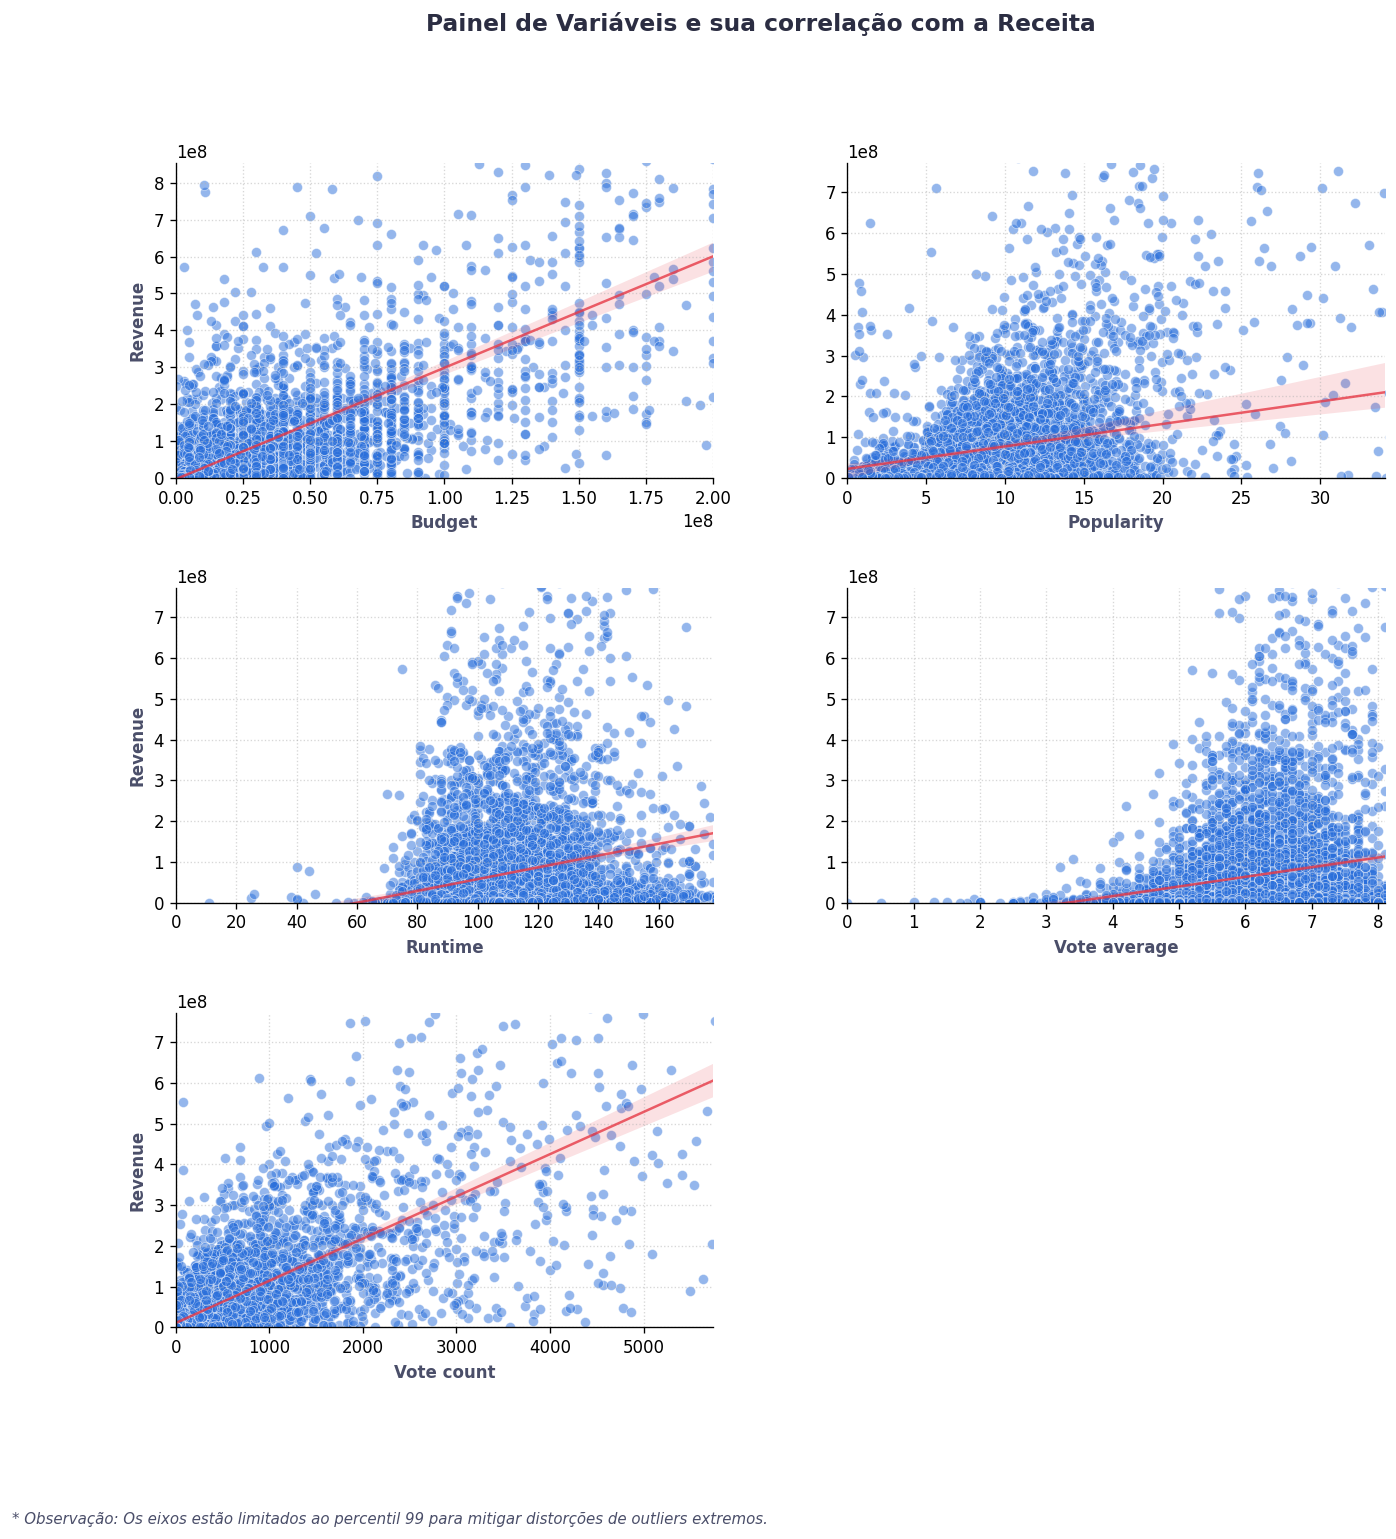

In [66]:
graf.grafico_corr_scatter(
    df_plot=df_movies,
    coluna_x=colunas_numericas.drop(['revenue', 'id']), 
    coluna_y='revenue',
    titulo='Painel de Variáveis e sua correlação com a Receita',
    quant_grafs=len(colunas_numericas.drop(['revenue', 'id']))
)

### Categorica VS Categorica

#### `genres` vs `production_companies`

In [67]:
contingencia_genres_companies = rsh.gerar_contingencia(
    df=df_movies, 
    coluna_linha='production_companies', 
    coluna_coluna='genres', 
    top_n_linhas=20, 
    top_n_colunas=20
)


display(tb.estilizar_tabela(
    df=contingencia_genres_companies,
    caption='Tabela de Contingência: Top 20 Produtoras vs Top 20 Gêneros'
))

genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,Gênero Não Identificado,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
production_companies,,,,,,,,,,,,,,,,,,,,
Canal+,43,29,4,120,57,8,296,10,15,16,2,25,24,7,28,97,12,79,21,4
Centre National de la Cinématographie (CNC),3,7,5,34,9,6,131,2,9,6,2,4,3,3,5,51,3,8,8,0
Columbia Pictures,106,67,20,187,62,2,201,44,34,0,0,13,21,15,27,98,30,86,14,23
Columbia Pictures Corporation,88,57,3,146,72,0,216,19,25,1,0,13,28,23,43,105,30,87,28,35
Companhia Não Identificada,920,338,280,2383,510,1743,3368,443,279,708,1133,201,745,315,297,1053,423,1129,130,90
France 2 Cinéma,3,10,0,62,18,5,116,3,2,3,0,12,0,3,7,46,1,18,10,1
Metro-Goldwyn-Mayer (MGM),149,115,14,342,129,6,553,57,44,2,3,30,56,109,73,325,44,150,51,57
Miramax Films,17,6,4,71,36,3,122,10,10,5,0,10,11,6,10,68,6,47,5,1
Mosfilm,14,27,2,74,8,3,113,17,17,2,1,25,1,0,3,50,7,3,25,1


In [68]:
# Executando o Teste do Qui-Quadrado
resultado_genres_companies = mt.testar_dependencia_categorica(
    contingencia_genres_companies
)

display(tb.estilizar_tabela(
    df=resultado_genres_companies,
    caption='Relatório: genres vs production_companies'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,9645.981036,0.000000,361


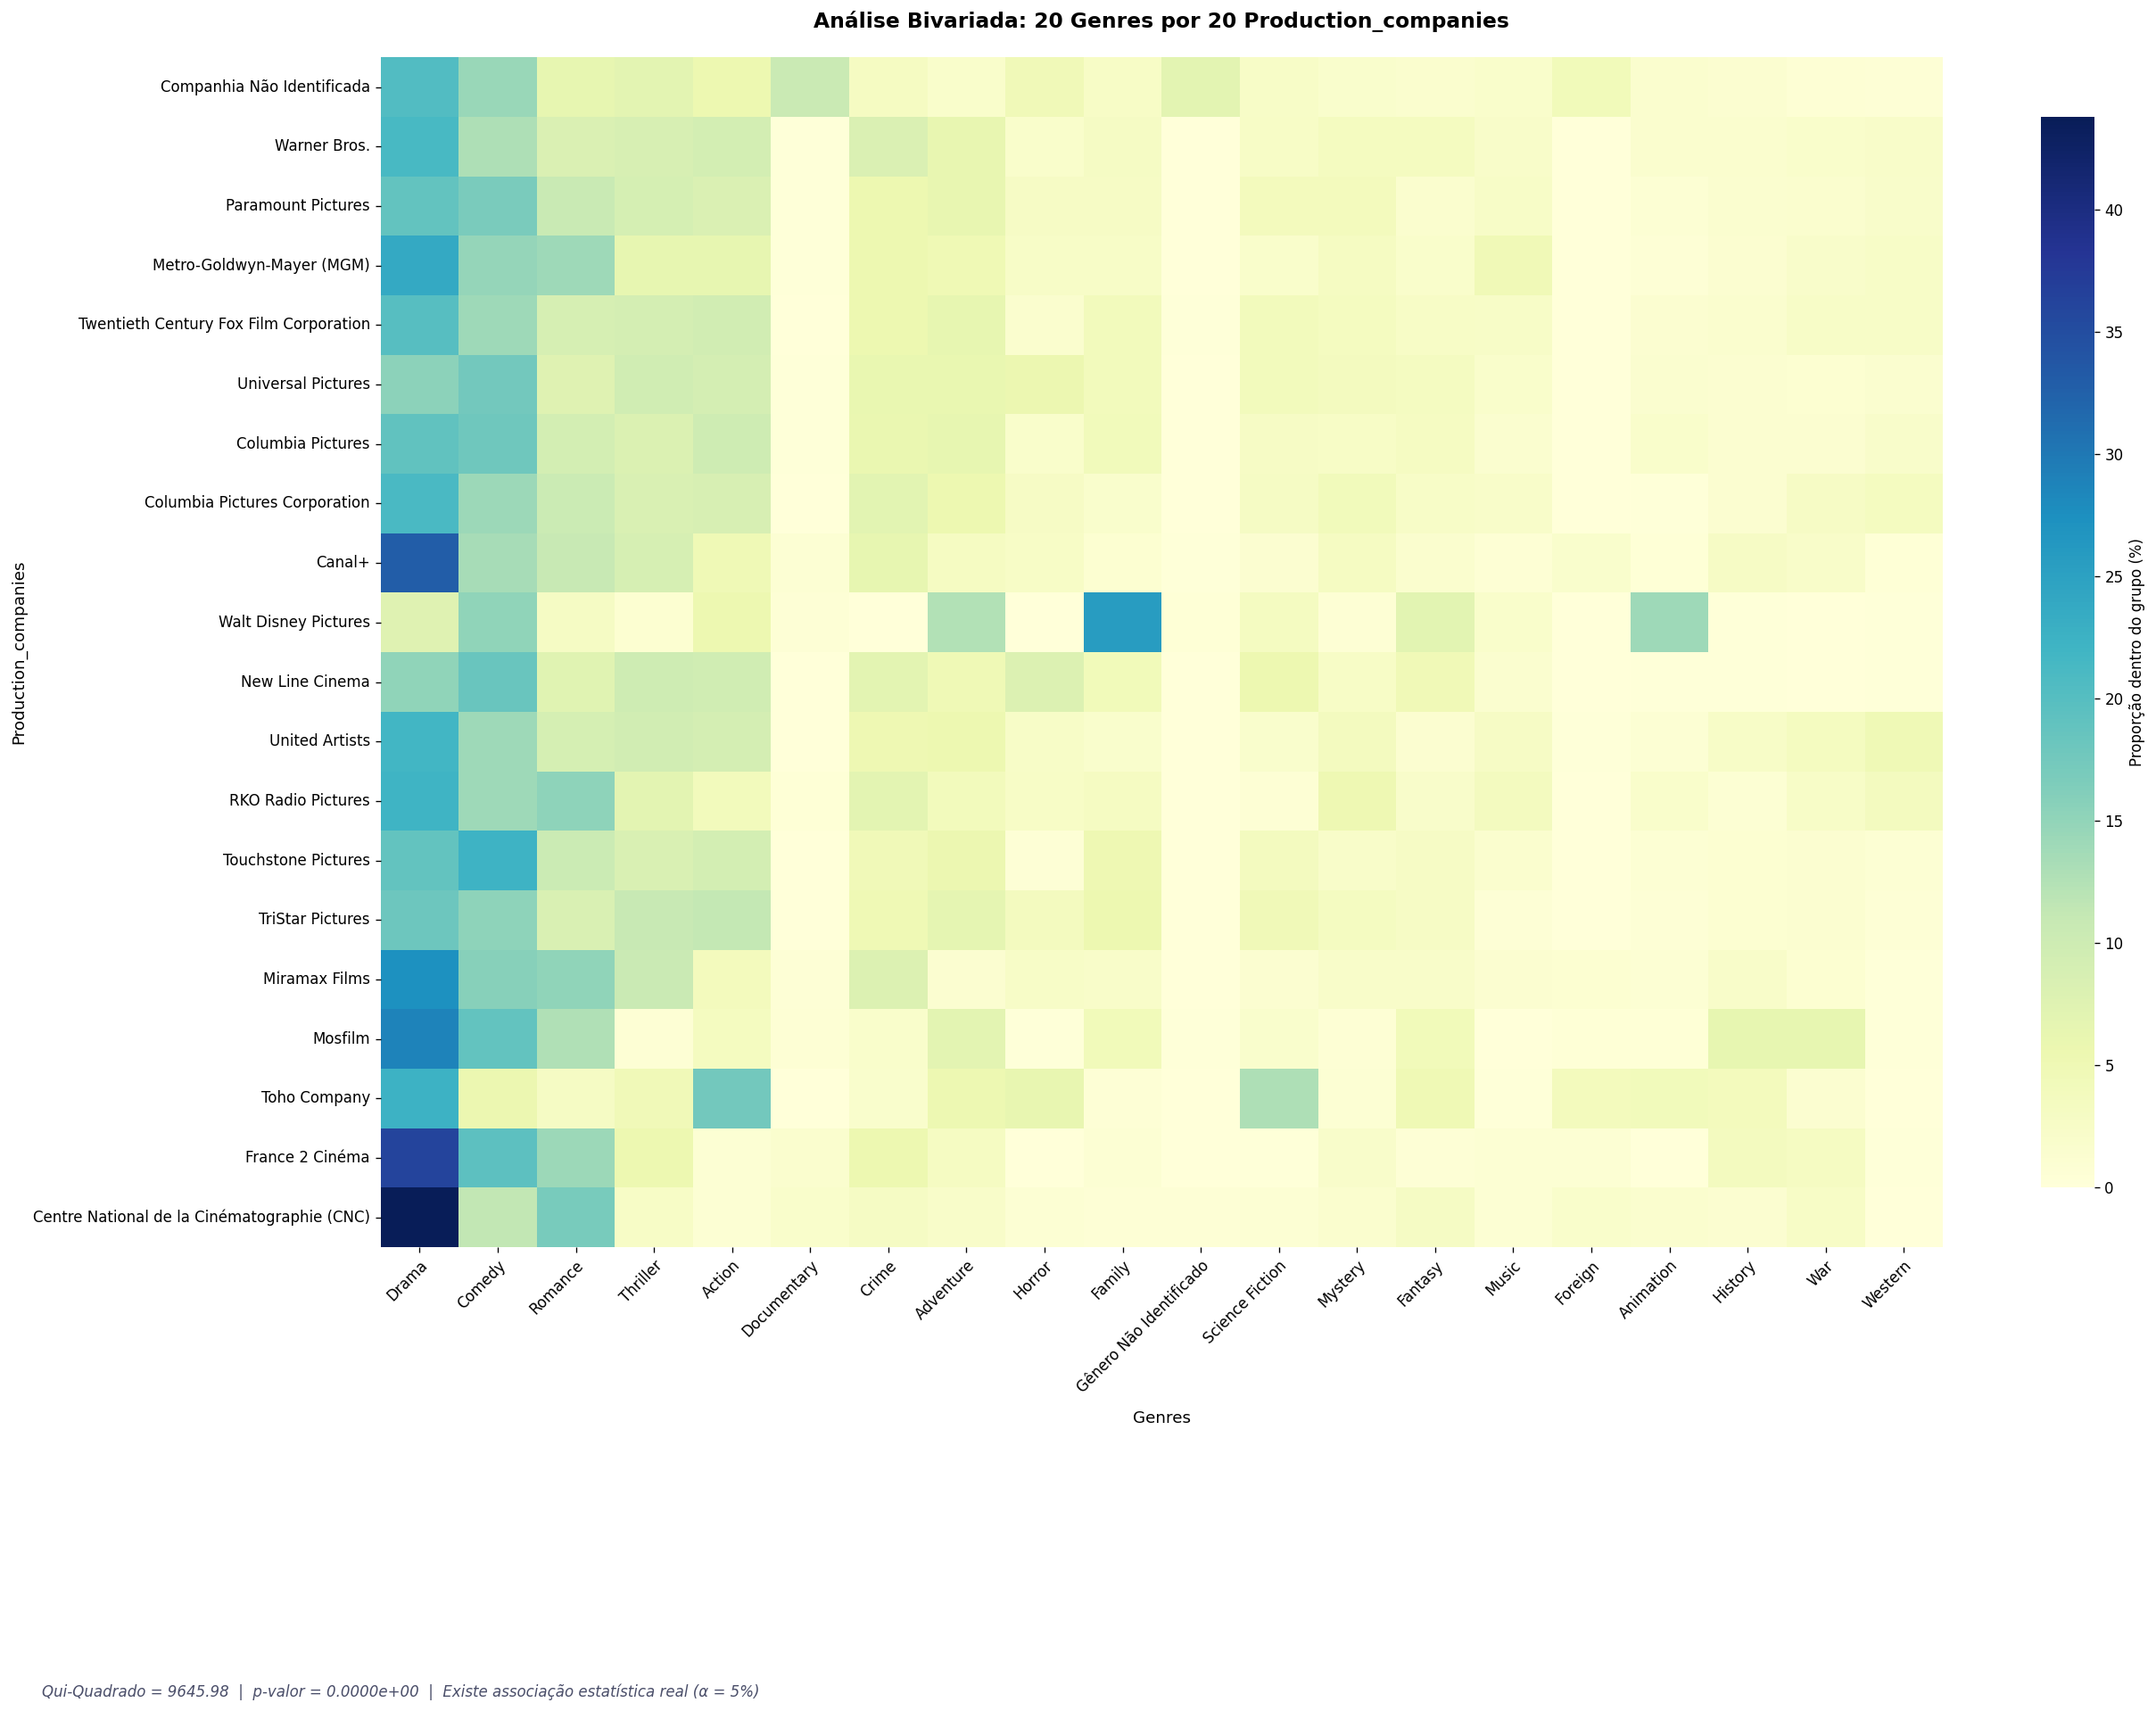

In [69]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_genres_companies,
    chi2=resultado_genres_companies['Qui-Quadrado'].iloc[0],
    p_valor=resultado_genres_companies['p-valor'].iloc[0],
    top_n=20
)

#### `genres` vs `production_countries`

In [70]:
contingencia_genres_countries = rsh.gerar_contingencia(
    df=df_movies, 
    coluna_linha='production_countries', 
    coluna_coluna='genres', 
    top_n_linhas=20, 
    top_n_colunas=20
)


display(tb.estilizar_tabela(
    df=contingencia_genres_countries,
    caption='Tabela de Contingência: Top 20 Países vs Top 20 Gêneros'
))

genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,Gênero Não Identificado,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
production_countries,,,,,,,,,,,,,,,,,,,,
Australia,102,68,22,142,55,29,273,48,32,21,3,21,87,15,53,76,66,154,18,10
Belgium,28,31,35,108,27,19,258,22,24,26,10,25,25,7,22,71,15,56,17,3
Canada,282,142,76,365,150,132,726,128,111,27,23,43,324,42,157,195,217,477,28,18
China,151,57,9,61,31,18,210,15,35,40,11,34,8,4,18,68,12,59,16,1
Denmark,24,22,20,101,38,37,234,29,12,18,8,15,22,4,16,40,14,60,12,2
Finland,17,12,9,110,27,32,162,16,12,12,17,13,7,18,8,33,8,28,15,0
France,300,231,117,1108,393,208,2326,106,209,166,74,203,202,77,201,694,123,504,139,38
Germany,242,174,67,525,194,178,1243,97,138,102,23,142,169,52,127,276,117,374,104,36
Hong Kong,415,77,4,165,105,9,228,10,51,98,6,26,37,4,14,66,29,133,12,4


In [71]:
# Executando o Teste do Qui-Quadrado
resultado_genres_countries = mt.testar_dependencia_categorica(
    contingencia_genres_countries
)

display(tb.estilizar_tabela(
    df=resultado_genres_countries,
    caption='Relatório: genres vs production_countries'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,17591.280320,0.000000,361


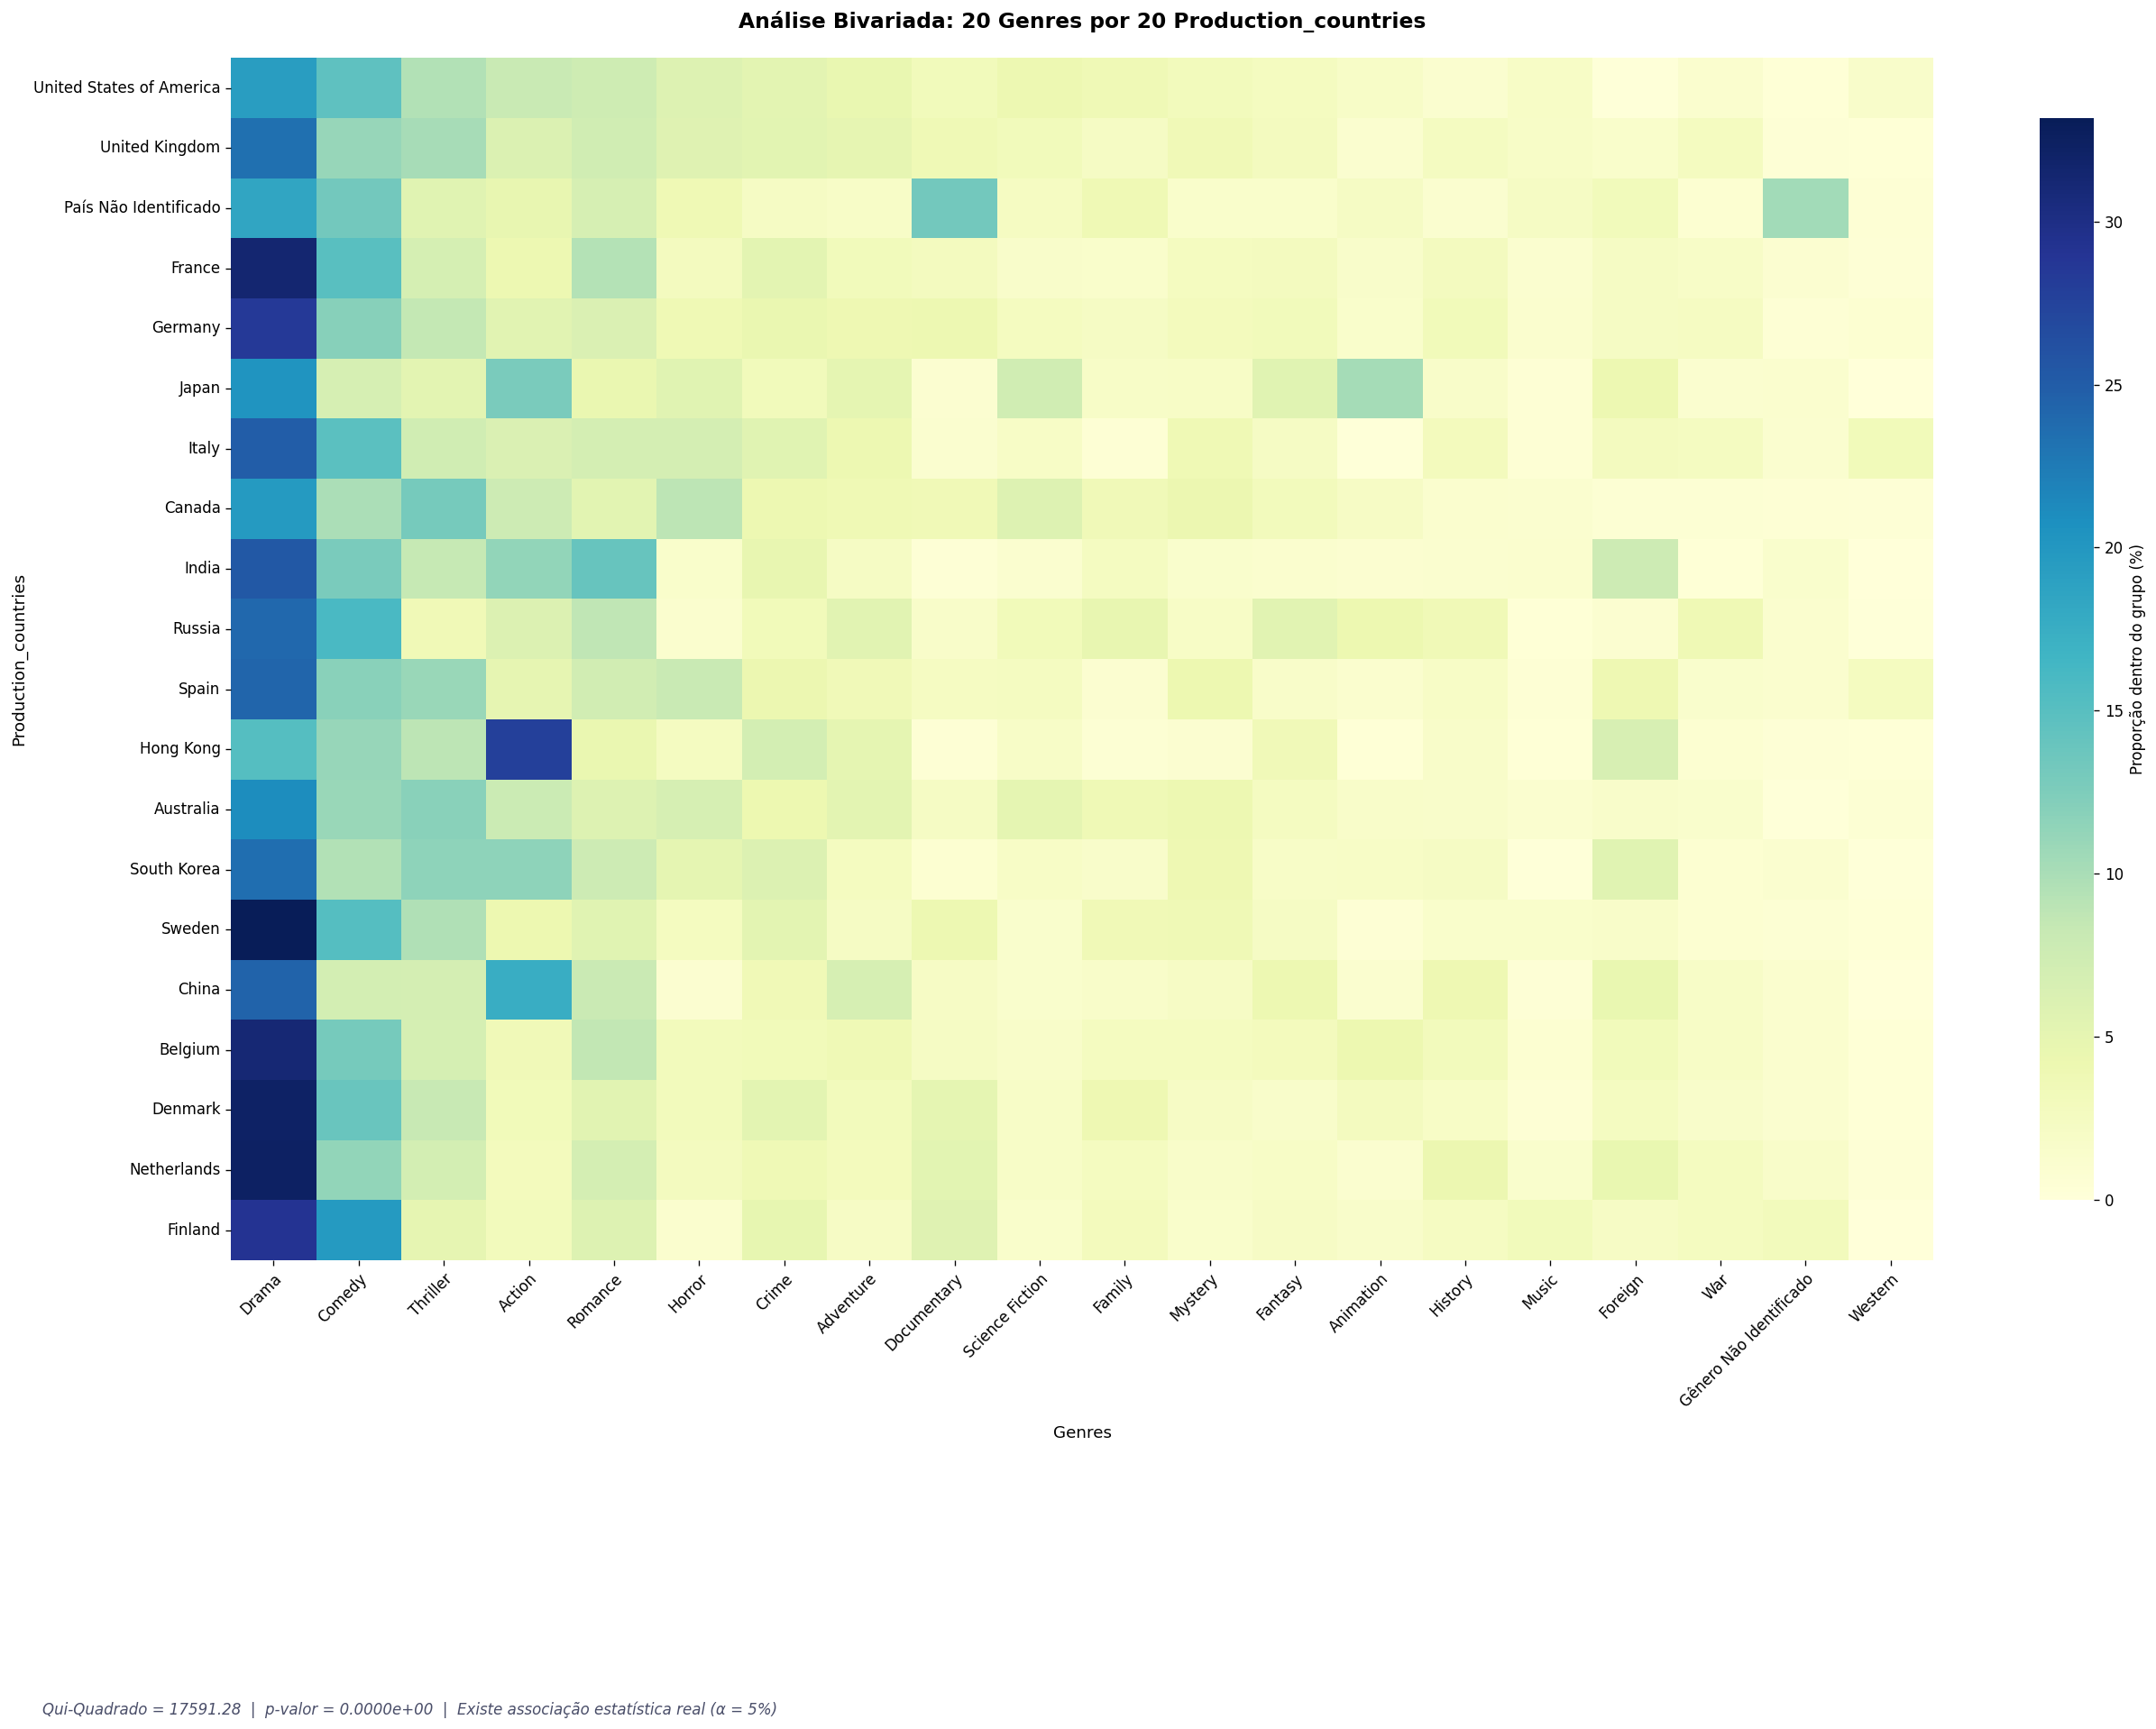

In [72]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_genres_countries,
    chi2=resultado_genres_countries['Qui-Quadrado'].iloc[0],
    p_valor=resultado_genres_countries['p-valor'].iloc[0],
    top_n=20
)

#### `genres` vs `original_language	`

In [73]:
contingencia_genres_language = rsh.gerar_contingencia(
    df=df_movies, 
    coluna_linha='original_language', 
    coluna_coluna='genres', 
    top_n_linhas=20, 
    top_n_colunas=20
)


display(tb.estilizar_tabela(
    df=contingencia_genres_language,
    caption='Tabela de Contingência: Top 20 Idiomas vs Top 20 Gêneros'
))

genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,Gênero Não Identificado,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
original_language,,,,,,,,,,,,,,,,,,,,
cn,220,28,0,111,79,1,112,2,27,42,2,9,26,1,10,38,15,90,1,1
cs,3,12,22,48,3,5,62,18,26,5,3,6,13,8,5,14,7,6,9,1
da,14,11,14,70,25,10,135,24,6,6,5,6,14,1,9,25,4,34,8,1
de,41,56,26,277,61,76,534,37,44,41,28,56,60,23,31,98,38,108,38,15
en,4554,2574,1187,8786,3028,2862,12495,2175,1541,625,985,836,3692,1256,1850,4566,2369,5795,844,770
es,55,26,19,247,70,45,499,13,26,96,33,15,91,10,44,138,31,157,10,16
fi,12,4,4,79,22,14,98,11,4,7,12,1,3,12,6,23,4,18,10,0
fr,153,123,85,782,221,99,1305,58,116,84,58,93,115,37,102,403,71,249,69,10
hi,124,16,0,151,62,1,291,14,8,97,23,12,15,15,16,178,8,90,4,0


In [74]:
# Executando o Teste do Qui-Quadrado
resultado_genres_language = mt.testar_dependencia_categorica(
    contingencia_genres_language
)

display(tb.estilizar_tabela(
    df=resultado_genres_language,
    caption='Relatório: genres vs original_language'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,7928.605381,0.000000,361


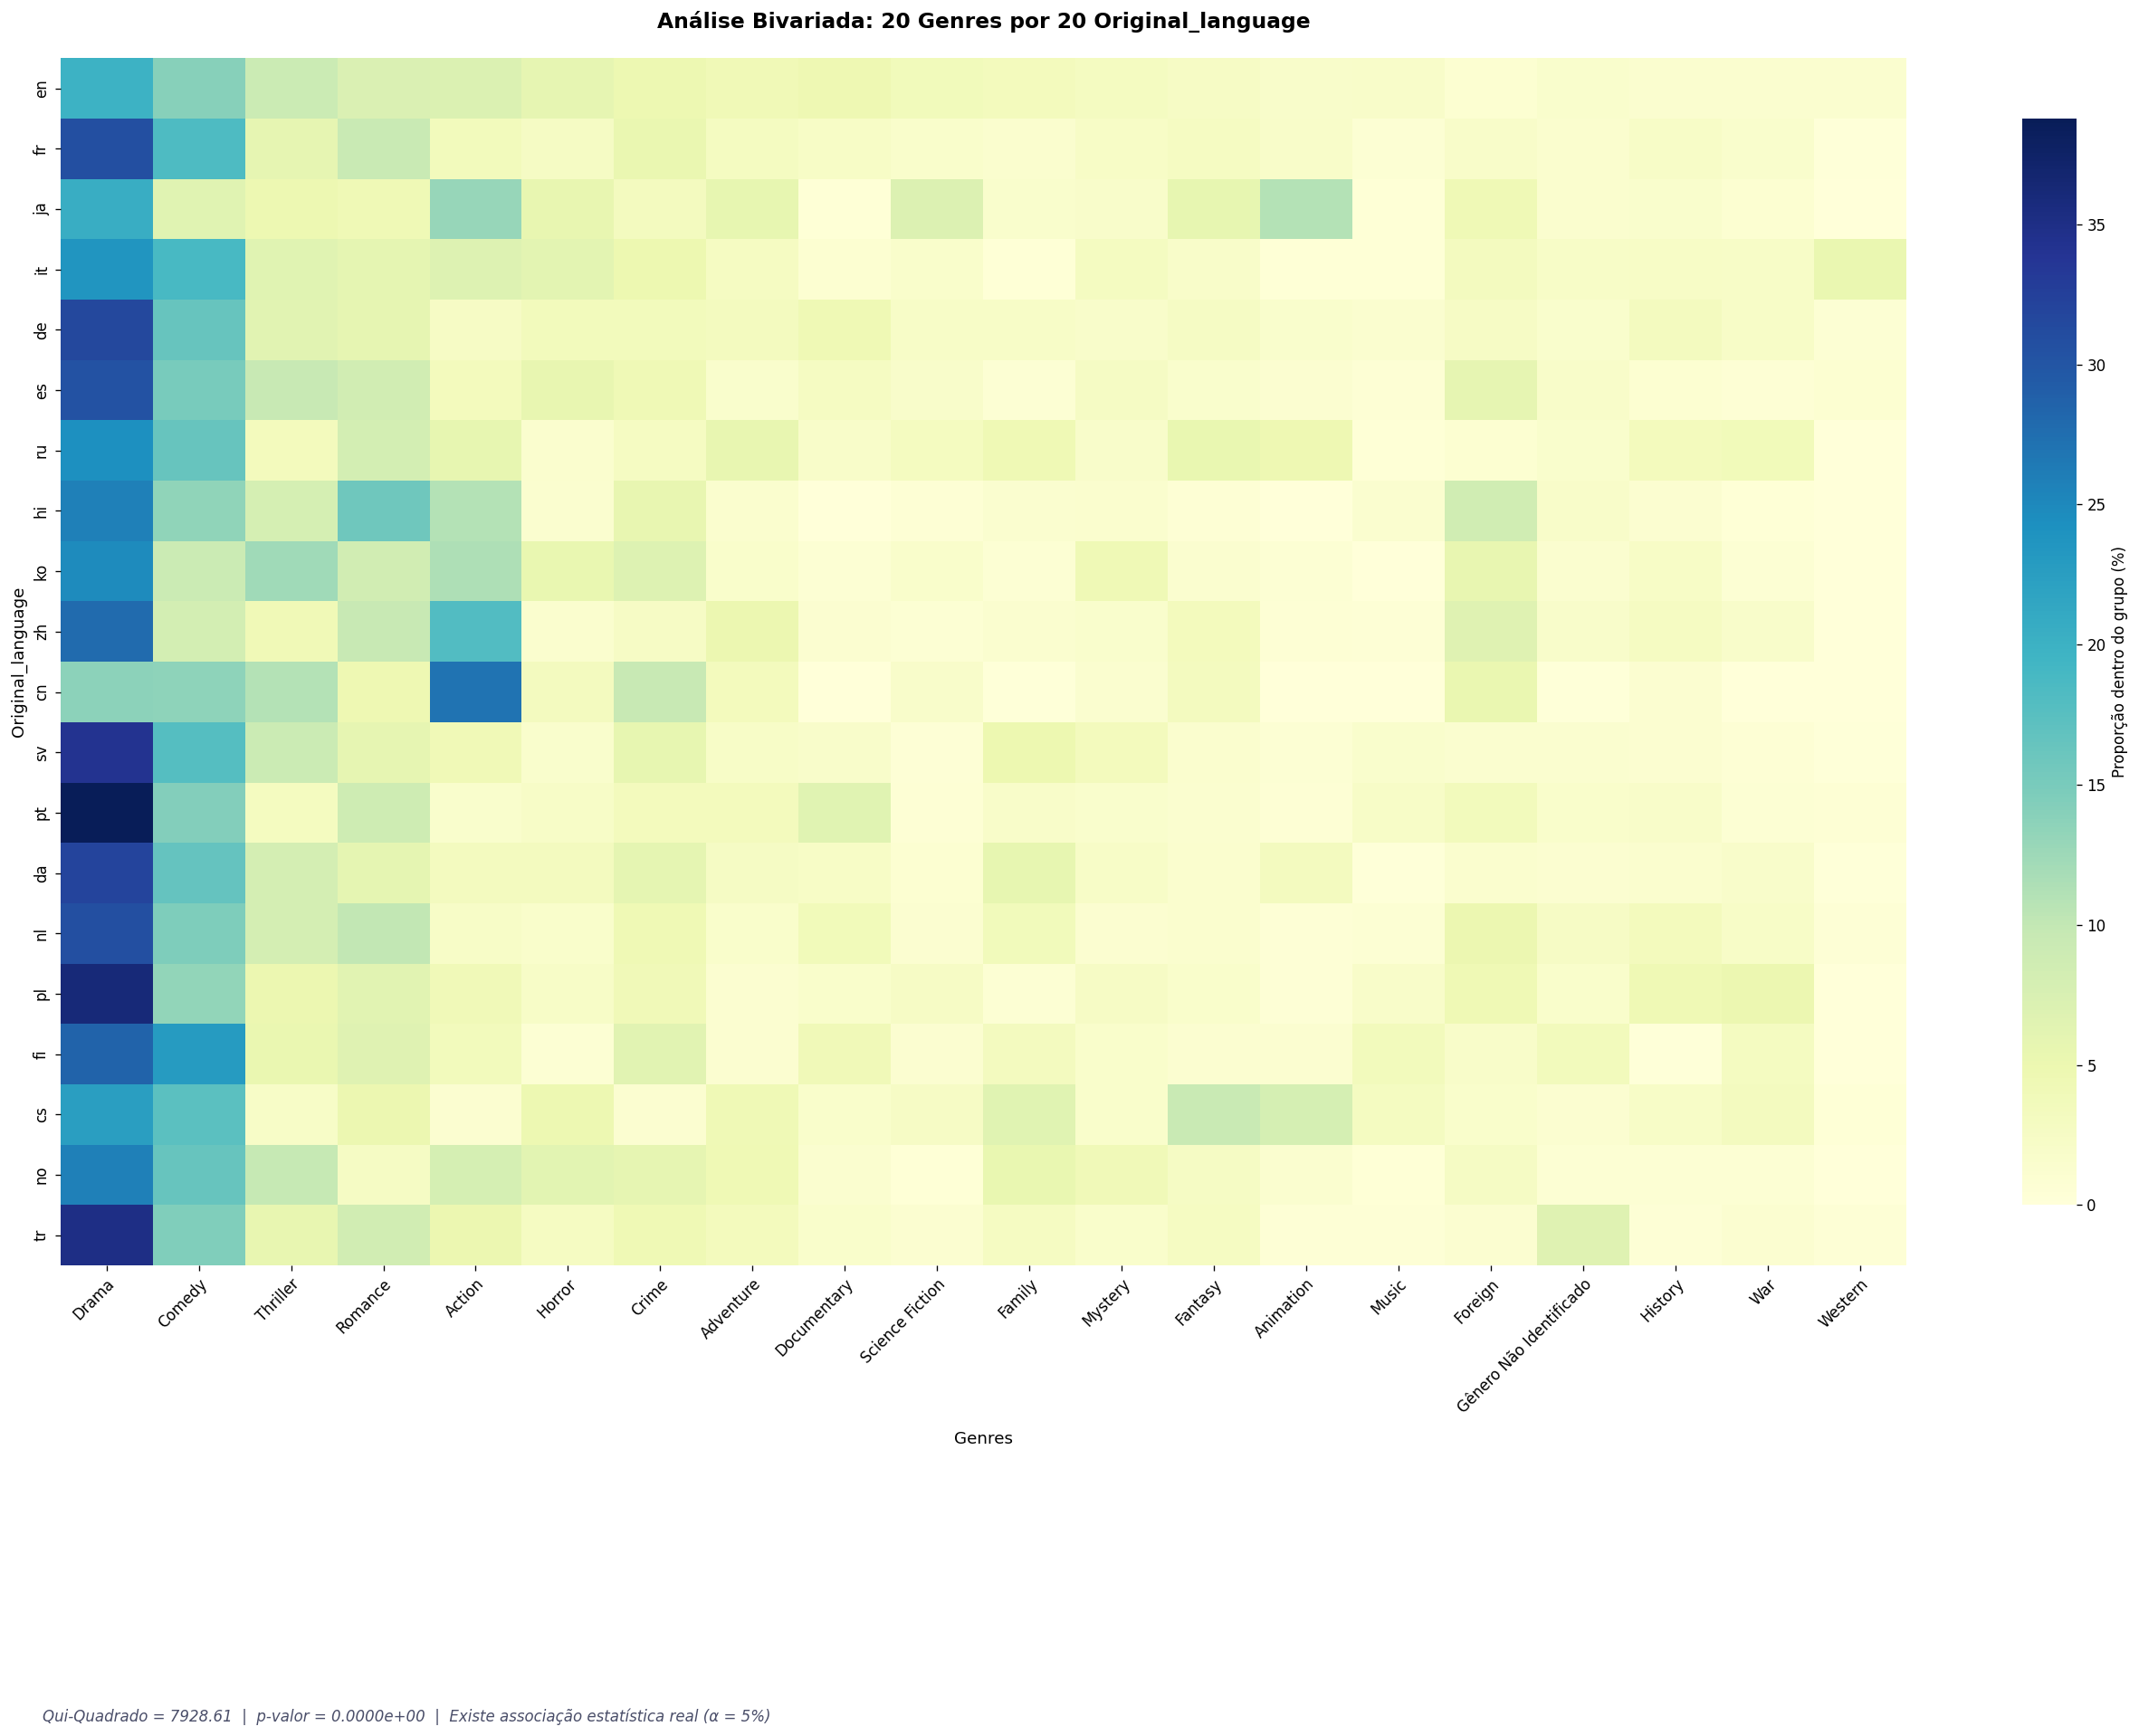

In [75]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_genres_language,
    chi2=resultado_genres_language['Qui-Quadrado'].iloc[0],
    p_valor=resultado_genres_language['p-valor'].iloc[0],
    top_n=20
)

#### `production_countries` vs `original_language`

In [76]:
contingencia_countries_language = rsh.gerar_contingencia(
    df=df_movies, 
    coluna_linha='original_language', 
    coluna_coluna='production_countries', 
    top_n_linhas=20, 
    top_n_colunas=20
)


display(tb.estilizar_tabela(
    df=contingencia_countries_language,
    caption='Tabela de Contingência: Top 20 Idiomas vs Top 20 Produtoras'
))

production_countries,Australia,Belgium,Canada,China,Denmark,France,Germany,Hong Kong,India,Italy,Japan,Mexico,Netherlands,País Não Identificado,Russia,South Korea,Spain,Sweden,United Kingdom,United States of America
original_language,,,,,,,,,,,,,,,,,,,,
cn,2,0,0,32,0,1,1,285,0,0,3,0,1,6,1,3,1,0,0,6
cs,0,0,1,0,1,4,10,0,0,1,4,0,0,4,0,0,0,0,10,3
da,0,3,0,0,204,16,18,0,0,7,0,0,5,10,0,0,0,43,8,3
de,4,7,5,1,4,62,754,0,0,18,1,2,6,47,3,2,6,4,17,47
en,536,148,1517,95,99,1122,894,126,150,502,239,111,133,3925,162,47,287,129,3755,19654
es,0,4,3,0,2,100,36,0,0,33,7,184,17,42,3,1,412,1,15,61
fi,0,2,0,1,1,3,2,0,0,0,0,0,2,17,1,0,1,9,2,0
fr,2,180,117,0,4,1935,131,2,1,232,17,3,9,86,6,1,37,7,58,104
hi,1,0,1,0,0,4,2,0,416,1,0,0,0,47,0,0,0,0,4,4


In [77]:
# Executando o Teste do Qui-Quadrado
resultado_countries_language = mt.testar_dependencia_categorica(
    contingencia_countries_language
)

display(tb.estilizar_tabela(
    df=resultado_countries_language,
    caption='Relatório: production_countries vs original_language'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,274657.197187,0.000000,361


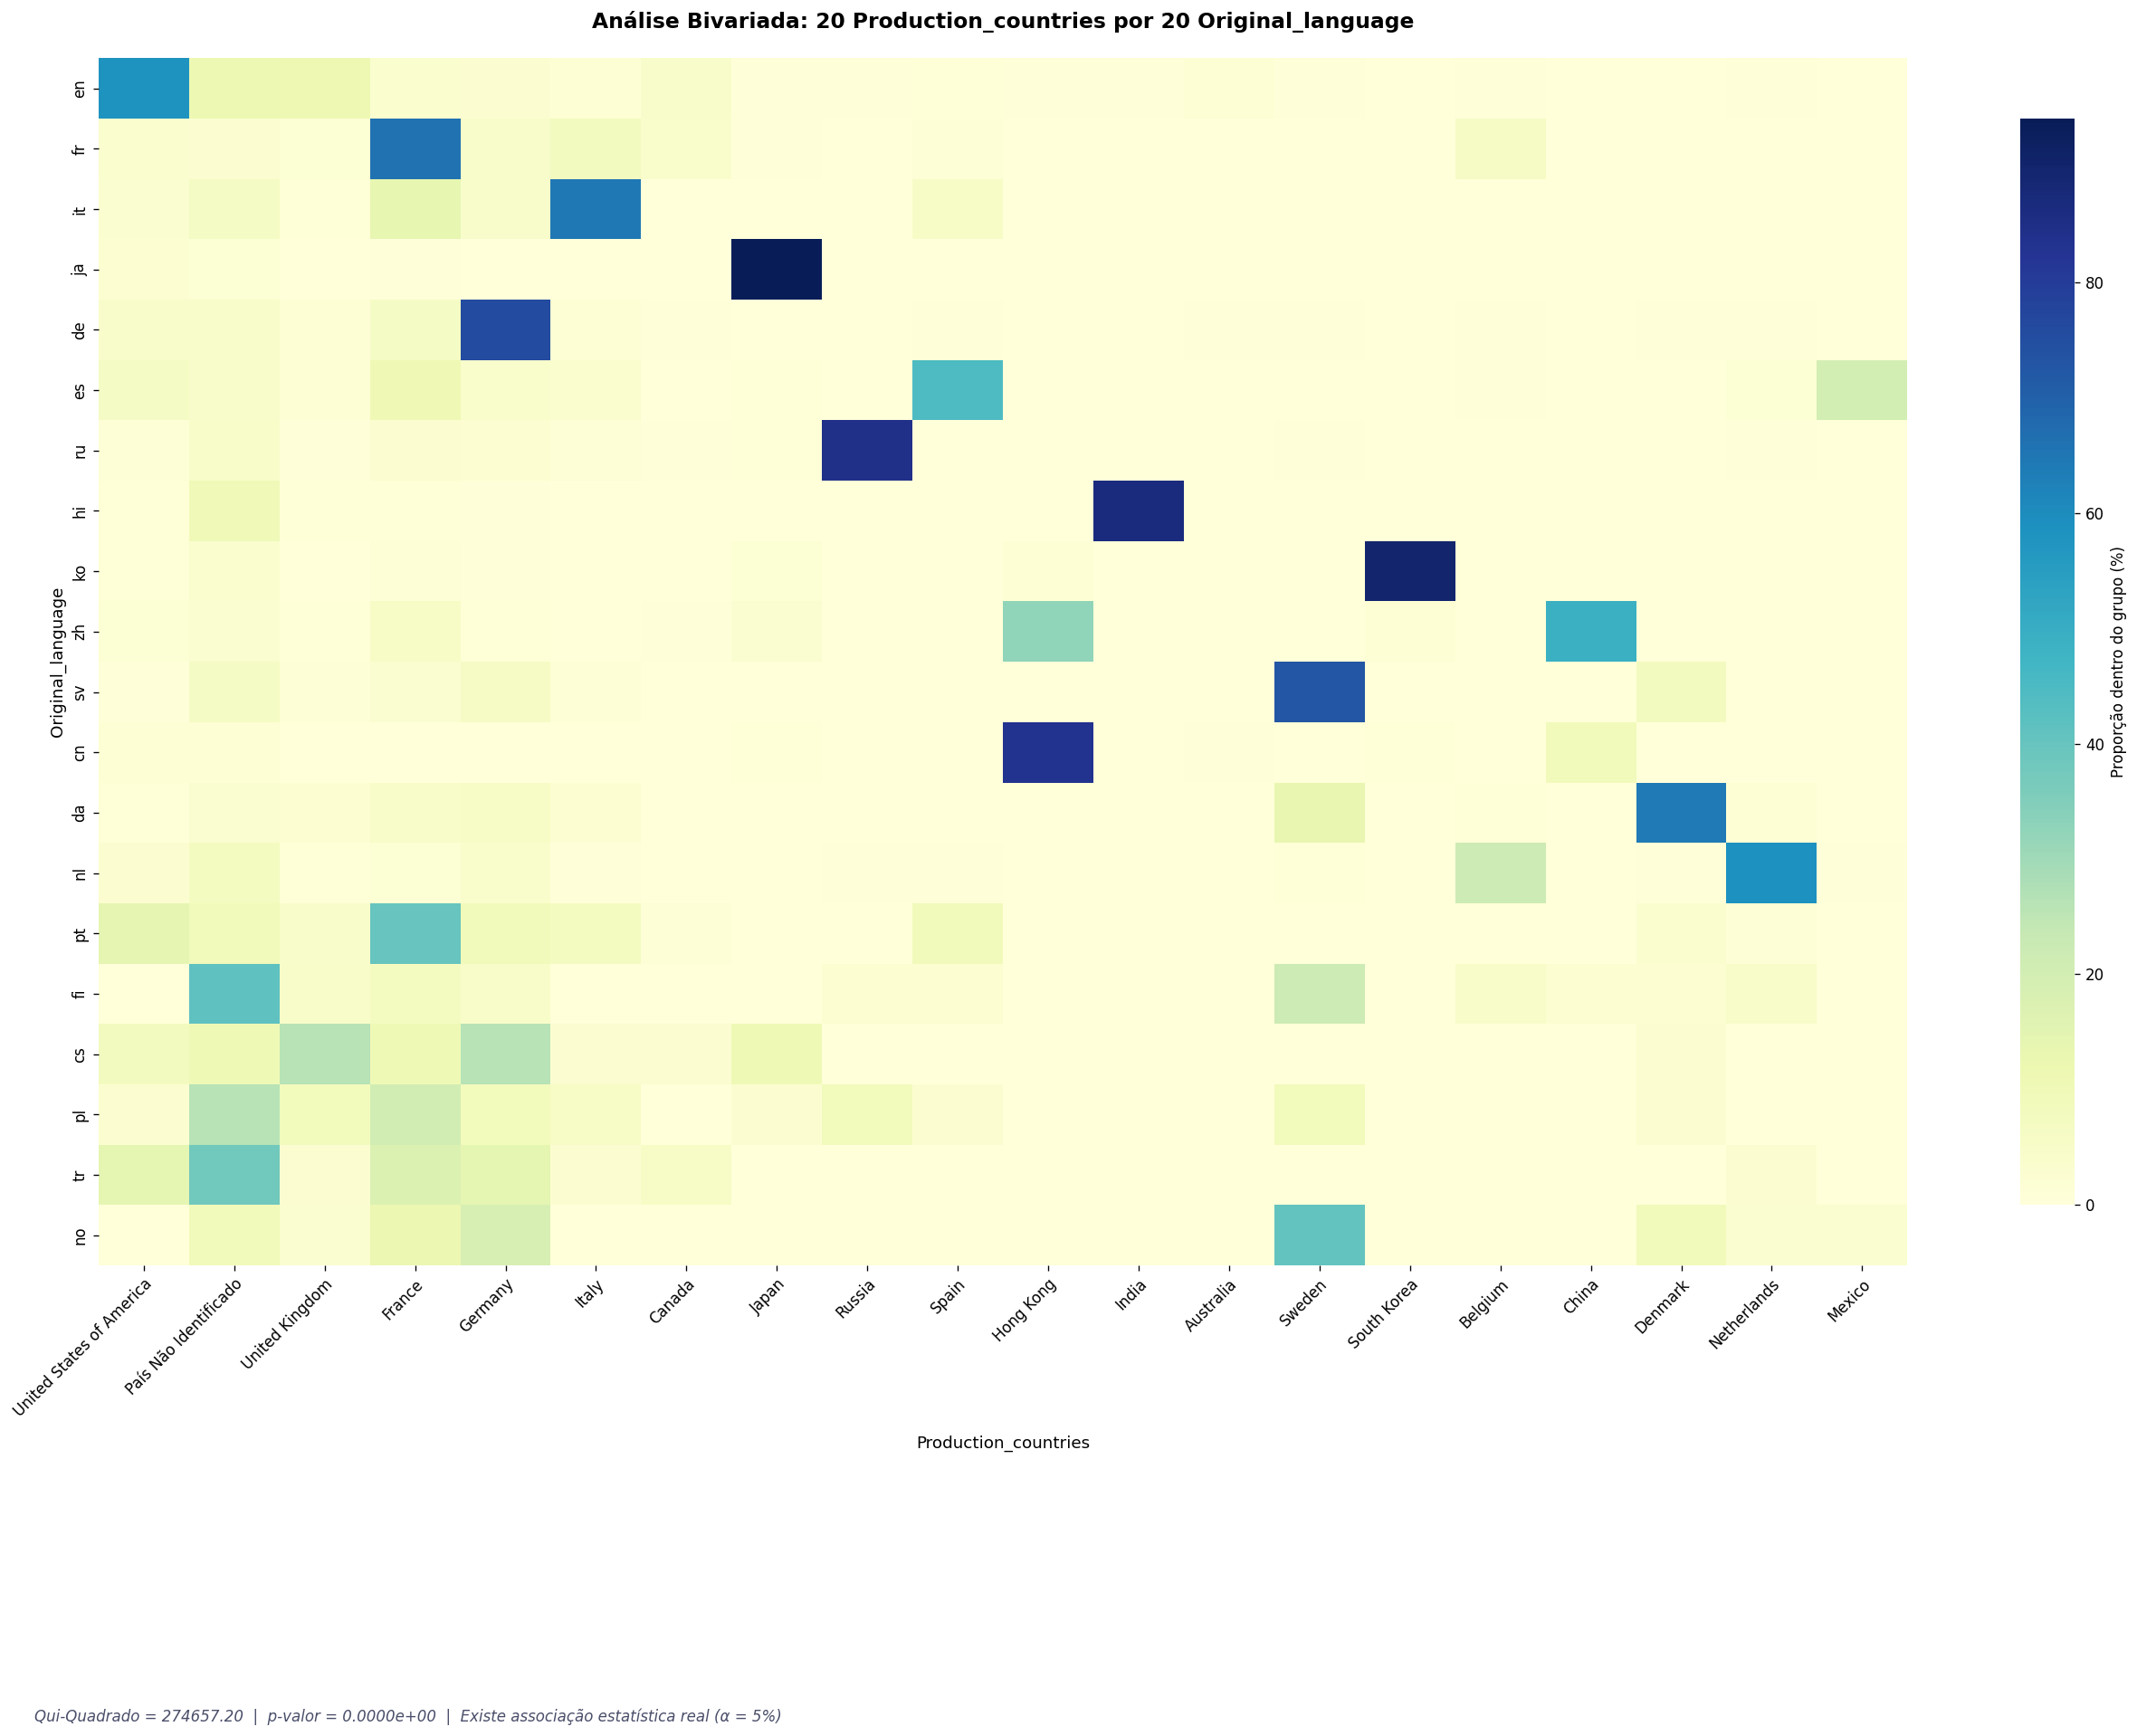

In [78]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_countries_language,
    chi2=resultado_countries_language['Qui-Quadrado'].iloc[0],
    p_valor=resultado_countries_language['p-valor'].iloc[0],
    top_n=20
)

# Continua

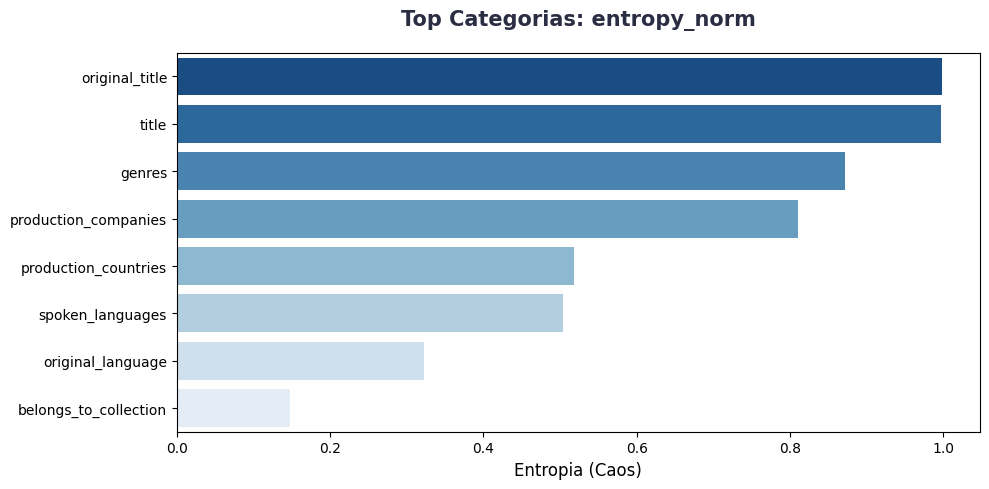

In [79]:
graf.grafico_metricas_categorias(
    relatorio_metrica=resumo_cols_categoricas,
    coluna='entropy_norm',
    x_label='Entropia (Caos)'
)